In [128]:
import requests
from fredapi import Fred
import pandas as pd
import plotly.graph_objects as go
import yfinance as yf
import pandas as pd
import numpy as np
import requests
import zipfile
import io
import plotly.express as px
import seaborn as sns
from plotly.subplots import make_subplots
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings('ignore', message='No frequency information')
from arch import arch_model
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
import pandas as pd


### To Do:
1. Data Getting ✅
2.  Data cleaning ✅
3. Merge Data with COT Data ✅
4. Feature Engineering ☑️
5. descriptive statistics ☑️
6. Pre Tests
7. Structural break testing
8. Run Model(s)
9. Diagnostics
10. Robustness Tests
11. Visualisations
12. Write Up

# Data Getting

### FRED Data

In [129]:
fred = Fred(api_key='40b5fe20eb1362f04fa6a2f3c6a86fed')

In [130]:
FRED_CODES = {
    'IRLTLT01JPM156N' : ['JPY 10Y', 'M'],
    'IR3TIB01JPM156N' : ['JPY 3M', 'M'], 
    'IRSTCI01JPM156N' : ['JPY Interbank', 'M'],
    'IRLTLT01USM156N' : ['US 10 Year', 'M'],
    'IR3TIB01USM156N' : ['US 3M', 'M' ],
    'IRSTCI01USM156N' : ['US Interbank', 'W']
    
}
# 'PPPTTLJPA618NUPN' : 'JPY PPP'
start_date = pd.to_datetime('2000-01-01').date()
end_date = pd.to_datetime('2026-01-01').date()

In [131]:
def get_fred_data(FRED_CODES,start_date , end_date):
    start_date = pd.to_datetime(start_date).date()
    end_date = pd.to_datetime(end_date).date()
    df_list = []
    ## get all series from FRED
    for code in FRED_CODES.keys():
        print(code,": ",FRED_CODES[code][0], "\n" )

        
        series = fred.get_series(code)
        series = series.to_frame(name=f'{FRED_CODES[code][0]}({FRED_CODES[code][1]})')

        series.index = pd.to_datetime(series.index)
        series = series.loc[start_date:end_date ]
        series.index = series.index.date
        
        df_list.append(series)

    ## Find highest Date and lowest date from all the series
    highest_start = start_date
    lowest_end = end_date
    freq_list = []
    for df in df_list:
        print(f"{df.columns.values.tolist()[0]}: ({df.index[0]} ->>, {df.index[-1]}), Freq: {df.columns.values.tolist()[0][-2]}")
        freq_list.append(df.columns.values.tolist()[0][-2])

        if df.index[0]>highest_start:
            highest_start = df.index[0]
            
        if df.index[-1]<lowest_end:
            lowest_end = df.index[-1]

    # Find lowest Frequency
    if "D" in freq_list:
        freq = 'D'
    elif "W" in freq_list:
        freq = 'W'
    elif "M" in freq_list:
        freq = 'ME'
    elif "Q" in freq_list:
        freq = 'Q'
    elif "Y" in freq_list:   
        freq = 'Y'
    else:
        freq = 'D'


    date_range = pd.date_range(start = highest_start, end = lowest_end, freq = freq)
    date_range

    Merged = pd.DataFrame()

    for i in range(len(df_list)):
        df_list[i] = df_list[i].reindex(date_range, method = 'ffill')
        df_list[i] = df_list[i].bfill()

    all_df = pd.concat(df_list, axis=1)
    return all_df

In [132]:
jap = get_fred_data(FRED_CODES, start_date='2016-01-01', end_date='2025-12-31')

IRLTLT01JPM156N :  JPY 10Y 

IR3TIB01JPM156N :  JPY 3M 

IRSTCI01JPM156N :  JPY Interbank 

IRLTLT01USM156N :  US 10 Year 

IR3TIB01USM156N :  US 3M 

IRSTCI01USM156N :  US Interbank 

JPY 10Y(M): (2016-01-01 ->>, 2025-12-01), Freq: M
JPY 3M(M): (2016-01-01 ->>, 2025-12-01), Freq: M
JPY Interbank(M): (2016-01-01 ->>, 2025-12-01), Freq: M
US 10 Year(M): (2016-01-01 ->>, 2025-12-01), Freq: M
US 3M(M): (2016-01-01 ->>, 2025-12-01), Freq: M
US Interbank(W): (2016-01-01 ->>, 2025-12-01), Freq: W


In [133]:
jap

,JPY 10Y(M),JPY 3M(M),JPY Interbank(M),US 10 Year(M),US 3M(M),US Interbank(W)
2016-01-03,0.095,0.16900,0.070,2.09,0.57,0.340000
2016-01-10,0.095,0.16900,0.070,2.09,0.57,0.340000
2016-01-17,0.095,0.16900,0.070,2.09,0.57,0.340000
2016-01-24,0.095,0.16900,0.070,2.09,0.57,0.340000
2016-01-31,0.095,0.16900,0.070,2.09,0.57,0.340000
...,...,...,...,...,...,...
2025-11-02,1.805,0.80636,0.478,4.09,3.86,3.882727
2025-11-09,1.805,0.80636,0.478,4.09,3.86,3.882727
2025-11-16,1.805,0.80636,0.478,4.09,3.86,3.882727
2025-11-23,1.805,0.80636,0.478,4.09,3.86,3.882727


In [134]:

financial = yf.download(tickers=['^VIX', 'DX-Y.NYB', 'CL=F', 'NKD=F'], start = '2016-01-01', end = '2025-12-02', interval = '5d')['Close']
financial = financial.reindex(jap.index, method='ffill').bfill()
financial.columns = ['Oil', 'DXY', 'Nikkei', 'VIX']

/var/folders/hs/v5c0lrnj61z3tp745vdhh0m40000gn/T/ipykernel_39560/1166312743.py:1: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  4 of 4 completed


In [135]:
financial_and_economics = pd.merge(left=jap, right=financial, left_index=True, right_index=True, how='right')
financial_and_economics

,JPY 10Y(M),JPY 3M(M),JPY Interbank(M),US 10 Year(M),US 3M(M),US Interbank(W),Oil,DXY,Nikkei,VIX
2016-01-03,0.095,0.16900,0.070,2.09,0.57,0.340000,33.970001,99.180000,18075.0,20.590000
2016-01-10,0.095,0.16900,0.070,2.09,0.57,0.340000,33.970001,99.180000,18075.0,20.590000
2016-01-17,0.095,0.16900,0.070,2.09,0.57,0.340000,31.410000,98.730003,17410.0,24.299999
2016-01-24,0.095,0.16900,0.070,2.09,0.57,0.340000,29.530001,99.059998,16480.0,26.690001
2016-01-31,0.095,0.16900,0.070,2.09,0.57,0.340000,31.450001,99.360001,17090.0,22.500000
...,...,...,...,...,...,...,...,...,...,...
2025-11-02,1.805,0.80636,0.478,4.09,3.86,3.882727,60.570000,99.529999,51405.0,16.910000
2025-11-09,1.805,0.80636,0.478,4.09,3.86,3.882727,60.560001,100.220001,51265.0,19.000000
2025-11-16,1.805,0.80636,0.478,4.09,3.86,3.882727,60.090000,99.269997,50490.0,19.830000
2025-11-23,1.805,0.80636,0.478,4.09,3.86,3.882727,59.439999,100.230003,49325.0,23.660000


### COT Data

In [136]:
def download_cot_data(years, report_type='combined'):
    """
    Downloads raw CFTC Traders in Financial Futures (TFF) data.

    Args:
        years       : list of int — e.g. [2020, 2021, 2022]
        report_type : 'futures' or 'combined' (futures + options)

    Returns:
        pd.DataFrame — raw unmodified TFF data
    """
    prefix_map = {
        'futures':  'fut_fin_xls',
        'combined': 'com_fin_xls',
    }
    assert report_type in prefix_map, f"report_type must be one of {list(prefix_map.keys())}"
    prefix = prefix_map[report_type]

    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)',
        'Referer':    'https://www.cftc.gov/MarketReports/CommitmentsofTraders/index.htm',
    }

    dfs = []
    for year in years:
        url = f"https://www.cftc.gov/files/dea/history/{prefix}_{year}.zip"
        print(f"Fetching {report_type} COT {year} from {url}...")
        try:
            response = requests.get(url, headers=headers, timeout=30)
            response.raise_for_status()
            zf  = zipfile.ZipFile(io.BytesIO(response.content))
            xls = zf.open(zf.namelist()[0]).read()
            dfs.append(pd.read_excel(io.BytesIO(xls), engine='xlrd'))
            print(f"  ✓ {year} fetched successfully")
        except requests.HTTPError as e:
            print(f"  ✗ HTTP error for {year}: {e}")
        except zipfile.BadZipFile:
            print(f"  ✗ Bad zip file for {year}")
        except Exception as e:
            print(f"  ✗ Unexpected error for {year}: {e}")

    if not dfs:
        raise RuntimeError("No data fetched — check years and network connection")

    return pd.concat(dfs, ignore_index=True)

In [137]:
def find_dominant_contracts(df, instrument_name):
    """
    For a given instrument, shows which contract names exist,
    how many weeks each was dominant, and the date range of dominance.

    Use this BEFORE updating INSTRUMENT_MAP to understand what to include.

    Args:
        df              : raw COT DataFrame
        instrument_name : str — search term e.g. 'EURO FX', 'NASDAQ', 'BITCOIN'
        top_n           : int — how many contracts to show

    Returns:
        pd.DataFrame — contract names, dominance count, date ranges
    """
    # Find all contracts matching the search term and print the variant names
    df_filtered = df[df['Market_and_Exchange_Names'].str.contains(instrument_name)]
    df_filtered = df_filtered[['Market_and_Exchange_Names', 'Report_Date_as_MM_DD_YYYY', 'Open_Interest_All']]
    df_filtered_pivot = df_filtered.pivot_table(
    index='Report_Date_as_MM_DD_YYYY',
    columns='Market_and_Exchange_Names',
    values='Open_Interest_All',
    aggfunc='first' ) # in case of duplicates, take first


    variant_names = (df_filtered_pivot.columns.values.tolist())
    print(f"Variants: For {instrument_name}: ") 
    for i in variant_names:
        print(i)
    if len(variant_names) == 0:
        print('Probably Searched Wrong')

    df_filtered_pivot['Total'] = df_filtered_pivot.sum(axis=1, )

    df_filtered_pivot_proportions = df_filtered_pivot.div(df_filtered_pivot['Total'], axis=0) * 100
    df_filtered_pivot_proportions = df_filtered_pivot_proportions.drop(columns='Total')
    return px.line(df_filtered_pivot_proportions)

In [138]:
def clean_financial_cot_data(df, instrument_map):
    ''' Dealer — financial institutions/dealers (often on the other side of client trades)
        Asset_Mgr — institutional investors like pension funds, mutual funds
        Lev_Money — leveraged money (hedge funds, CTAs)
        Other_Rept — other reportable traders
        NonRept — non-reportable (small traders below reporting thresholds)
        Traders - it's counting number of traders, knowing 47 dealers are long tells you less than knowing their total position size
        Concentration Report - Shows what % of open interest the top 4 and top 8 traders control'''
    
    # take only the columns we need
    df = df[['Market_and_Exchange_Names', 
    'Report_Date_as_MM_DD_YYYY', 
    'Open_Interest_All', 
    'Dealer_Positions_Long_All', 'Dealer_Positions_Short_All',
    'Asset_Mgr_Positions_Long_All','Asset_Mgr_Positions_Short_All',
    'Lev_Money_Positions_Long_All', 'Lev_Money_Positions_Short_All'
    ]]


    df['Report_Date_as_MM_DD_YYYY'] = pd.to_datetime(df['Report_Date_as_MM_DD_YYYY'])
    df = df.sort_values('Report_Date_as_MM_DD_YYYY')

    df['Instrument'] = df['Market_and_Exchange_Names'].map(instrument_map)
    df = df[df['Instrument'].notna()].copy()

    cols_to_sum = df.columns.values.tolist()
    cols_to_sum.remove('Market_and_Exchange_Names')
    cols_to_sum.remove('Report_Date_as_MM_DD_YYYY')
    cols_to_sum.remove('Instrument')
    df = (
    df.groupby(['Instrument', 'Report_Date_as_MM_DD_YYYY'])[cols_to_sum]
    .sum()
    .reset_index()
    )


    return df

In [139]:
def process_COT(df_cot, instrument, start_date, end_date):
    """
    Args:
        df_cot      : cleaned COT dataframe (output of clean_cot_data())
        instrument  : str — e.g. 'SP500'
        start_date  : str — e.g. '2020-01-01'
        end_date    : str — e.g. '2022-12-31'
    """

    df_clean = df_cot[
    (df_cot['Instrument'] == instrument) &
    (df_cot['Report_Date_as_MM_DD_YYYY'] >= start_date) &
    (df_cot['Report_Date_as_MM_DD_YYYY'] <= end_date)
    ].copy()

    df_clean["Dealer Net"] = df_clean['Dealer_Positions_Long_All'] - df_clean['Dealer_Positions_Short_All']
    df_clean["Asset Manager Net"] = df_clean['Asset_Mgr_Positions_Long_All'] - df_clean['Asset_Mgr_Positions_Short_All'] 
    df_clean["Levered Net"] = df_clean['Lev_Money_Positions_Long_All'] - df_clean['Lev_Money_Positions_Short_All']

    df_clean["Dealer Long Proportion"] = df_clean['Dealer_Positions_Long_All']/df_clean['Open_Interest_All']
    df_clean["Asset Manager Long Proportion"] = df_clean['Asset_Mgr_Positions_Long_All']/df_clean['Open_Interest_All']
    df_clean["Levered Long Proportion"] = df_clean['Lev_Money_Positions_Long_All']/df_clean['Open_Interest_All']

    df_clean["Dealer Short Proportion"] = df_clean['Dealer_Positions_Short_All']/df_clean['Open_Interest_All']
    df_clean["Asset Manager Short Proportion"] = df_clean['Asset_Mgr_Positions_Short_All']/df_clean['Open_Interest_All']
    df_clean["Levered Short Proportion"] = df_clean['Lev_Money_Positions_Short_All']/df_clean['Open_Interest_All']


    df_clean["Dealer Crowding"] = (df_clean['Dealer_Positions_Long_All']+df_clean['Dealer_Positions_Short_All'])/df_clean['Open_Interest_All']
    df_clean["Asset Manager Crowding"] = (df_clean['Asset_Mgr_Positions_Long_All']+df_clean['Asset_Mgr_Positions_Short_All'])/df_clean['Open_Interest_All']
    df_clean["Levered Manager Crowding"] = (df_clean['Lev_Money_Positions_Long_All']+df_clean['Lev_Money_Positions_Short_All'])/df_clean['Open_Interest_All']

    df_clean["Dealer Intensity"] = df_clean["Dealer Net"] / (df_clean['Dealer_Positions_Long_All'] + df_clean['Dealer_Positions_Short_All'])
    df_clean["Asset Manager Intensity"] = df_clean["Asset Manager Net"] / (df_clean['Asset_Mgr_Positions_Long_All'] + df_clean['Asset_Mgr_Positions_Short_All'])
    df_clean["Levered Directional Intensity"] = df_clean["Levered Net"] / (df_clean['Lev_Money_Positions_Long_All'] + df_clean['Lev_Money_Positions_Short_All'])
    

    
    ticker = TICKER_MAP[instrument]
    spy = yf.download(tickers=ticker, start=start_date, end=end_date)['Close']

    spy_tuesday = spy[spy.index.dayofweek == 1]
    spy_tuesday.index.name = 'Report_Date_as_MM_DD_YYYY'
    spy_tuesday.name = 'Price_Close'  # rename the Series before merging

    df_clean_merged = df_clean.merge(spy_tuesday, on='Report_Date_as_MM_DD_YYYY', how='inner')
    df_clean_merged = df_clean_merged.rename(columns={ticker: 'Price_Close'})
    df_clean_merged

    return df_clean_merged

In [140]:
cot_raw = download_cot_data([2016, 2017, 2018, 2019,2020, 2021, 2022, 2023, 2024, 2025, 2026])
cot_raw

Fetching combined COT 2016 from https://www.cftc.gov/files/dea/history/com_fin_xls_2016.zip...
  ✓ 2016 fetched successfully
Fetching combined COT 2017 from https://www.cftc.gov/files/dea/history/com_fin_xls_2017.zip...
  ✓ 2017 fetched successfully
Fetching combined COT 2018 from https://www.cftc.gov/files/dea/history/com_fin_xls_2018.zip...
  ✓ 2018 fetched successfully
Fetching combined COT 2019 from https://www.cftc.gov/files/dea/history/com_fin_xls_2019.zip...
  ✓ 2019 fetched successfully
Fetching combined COT 2020 from https://www.cftc.gov/files/dea/history/com_fin_xls_2020.zip...
  ✓ 2020 fetched successfully
Fetching combined COT 2021 from https://www.cftc.gov/files/dea/history/com_fin_xls_2021.zip...
  ✓ 2021 fetched successfully
Fetching combined COT 2022 from https://www.cftc.gov/files/dea/history/com_fin_xls_2022.zip...
  ✓ 2022 fetched successfully
Fetching combined COT 2023 from https://www.cftc.gov/files/dea/history/com_fin_xls_2023.zip...
  ✓ 2023 fetched successfully


,Market_and_Exchange_Names,As_of_Date_In_Form_YYMMDD,Report_Date_as_MM_DD_YYYY,CFTC_Contract_Market_Code,CFTC_Market_Code,CFTC_Region_Code,CFTC_Commodity_Code,Open_Interest_All,Dealer_Positions_Long_All,Dealer_Positions_Short_All,...,Conc_Gross_LE_4_TDR_Short_All,Conc_Gross_LE_8_TDR_Long_All,Conc_Gross_LE_8_TDR_Short_All,Conc_Net_LE_4_TDR_Long_All,Conc_Net_LE_4_TDR_Short_All,Conc_Net_LE_8_TDR_Long_All,Conc_Net_LE_8_TDR_Short_All,Contract_Units,CFTC_SubGroup_Code,FutOnly_or_Combined
0,CANADIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE,161227,2016-12-27,090741,CME,0,90,112602,7528,10858,...,13.3,35.9,25.1,23.4,13.3,34.9,25.0,"(CONTRACTS OF CAD 100,000)",F10,Combined
1,CANADIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE,161220,2016-12-20,090741,CME,0,90,123125,18384,19960,...,18.7,38.8,30.2,25.8,18.1,35.2,28.3,"(CONTRACTS OF CAD 100,000)",F10,Combined
2,CANADIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE,161213,2016-12-13,090741,CME,0,90,130515,22389,18061,...,19.1,39.4,33.0,26.4,19.1,36.9,31.9,"(CONTRACTS OF CAD 100,000)",F10,Combined
3,CANADIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE,161206,2016-12-06,090741,CME,0,90,128355,29040,16822,...,18.8,42.8,32.6,29.9,18.8,39.0,30.2,"(CONTRACTS OF CAD 100,000)",F10,Combined
4,CANADIAN DOLLAR - CHICAGO MERCANTILE EXCHANGE,161129,2016-11-29,090741,CME,0,90,134842,39754,18067,...,17.3,47.7,29.2,35.0,16.1,44.7,26.4,"(CONTRACTS OF CAD 100,000)",F10,Combined
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27354,BBG COMMODITY - CHICAGO BOARD OF TRADE,260203,2026-02-03,221602,CBT,0,221,183456,126257,166798,...,88.7,89.2,96.6,82.0,88.6,87.3,95.0,($100 X INDEX),F90,Combined
27355,BBG COMMODITY - CHICAGO BOARD OF TRADE,260127,2026-01-27,221602,CBT,0,221,188271,125275,172650,...,89.4,89.8,96.8,82.8,89.4,87.9,95.4,($100 X INDEX),F90,Combined
27356,BBG COMMODITY - CHICAGO BOARD OF TRADE,260120,2026-01-20,221602,CBT,0,221,189350,125416,171958,...,88.5,89.7,96.0,82.6,88.5,87.7,94.8,($100 X INDEX),F90,Combined
27357,BBG COMMODITY - CHICAGO BOARD OF TRADE,260113,2026-01-13,221602,CBT,0,221,189092,125364,171894,...,88.6,89.7,96.2,82.7,88.6,87.8,95.0,($100 X INDEX),F90,Combined


In [141]:
find_dominant_contracts(cot_raw, 'YEN')

Variants: For YEN: 
EURO FX/JAPANESE YEN XRATE - CHICAGO MERCANTILE EXCHANGE
JAPANESE YEN - CHICAGO MERCANTILE EXCHANGE
NIKKEI STOCK AVERAGE YEN DENOM - CHICAGO MERCANTILE EXCHANGE


In [142]:
INSTRUMENT_MAP = {
    'JAPANESE YEN - CHICAGO MERCANTILE EXCHANGE': 'YEN',
    
}

In [143]:
TICKER_MAP = {
    'YEN':   'JPY=X',
}

In [144]:
cot_clean = clean_financial_cot_data(cot_raw, INSTRUMENT_MAP)

/var/folders/hs/v5c0lrnj61z3tp745vdhh0m40000gn/T/ipykernel_39560/2476550818.py:20: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [145]:
processed_cot_1 = process_COT(cot_clean, 'YEN', '2016-01-01', '2025-12-31')
processed_cot_1

/var/folders/hs/v5c0lrnj61z3tp745vdhh0m40000gn/T/ipykernel_39560/1062367617.py:40: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


,Instrument,Report_Date_as_MM_DD_YYYY,Open_Interest_All,Dealer_Positions_Long_All,Dealer_Positions_Short_All,Asset_Mgr_Positions_Long_All,Asset_Mgr_Positions_Short_All,Lev_Money_Positions_Long_All,Lev_Money_Positions_Short_All,Dealer Net,...,Dealer Short Proportion,Asset Manager Short Proportion,Levered Short Proportion,Dealer Crowding,Asset Manager Crowding,Levered Manager Crowding,Dealer Intensity,Asset Manager Intensity,Levered Directional Intensity,Price_Close
0,YEN,2016-01-05,251021,72877,35354,28539,70104,49114,73559,37523,...,0.140841,0.279275,0.293039,0.431163,0.392967,0.488696,0.346694,-0.421368,-0.199270,119.467003
1,YEN,2016-01-12,266593,71565,70481,31134,65068,64944,65160,1084,...,0.264377,0.244072,0.244418,0.532820,0.360857,0.488025,0.007631,-0.352737,-0.001660,117.650002
2,YEN,2016-01-19,276022,67894,85088,31411,61735,70932,62053,-17194,...,0.308265,0.223660,0.224812,0.554238,0.337459,0.481791,-0.112392,-0.325553,0.066767,117.384003
3,YEN,2016-01-26,281013,63877,94169,30391,58783,77541,60160,-30292,...,0.335105,0.209182,0.214083,0.562415,0.317331,0.490016,-0.191666,-0.318389,0.126223,118.227997
4,YEN,2016-02-02,271193,67887,72154,24325,59112,71942,57619,-4267,...,0.266061,0.217970,0.212465,0.516389,0.307666,0.477745,-0.030470,-0.416925,0.110550,120.839996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510,YEN,2025-12-02,425678,24777,109840,132191,58509,45617,116425,-85063,...,0.258035,0.137449,0.273505,0.316241,0.447991,0.380668,-0.631889,0.386377,-0.436973,155.557007
511,YEN,2025-12-09,493271,37488,103331,136583,59340,43425,136038,-65843,...,0.209481,0.120299,0.275788,0.285480,0.397191,0.363822,-0.467572,0.394252,-0.516056,155.843994
512,YEN,2025-12-16,413072,8134,61982,109056,50405,40750,126907,-53848,...,0.150051,0.122025,0.307227,0.169743,0.386037,0.405878,-0.767984,0.367808,-0.513888,155.014999
513,YEN,2025-12-23,320540,8815,60165,102816,53146,32172,115145,-51350,...,0.187699,0.165801,0.359222,0.215199,0.486560,0.459590,-0.744419,0.318475,-0.563228,156.876999


In [146]:
processed_cot_1 = processed_cot_1.set_index('Report_Date_as_MM_DD_YYYY')

In [147]:
processed_cot_1

,Instrument,Open_Interest_All,Dealer_Positions_Long_All,Dealer_Positions_Short_All,Asset_Mgr_Positions_Long_All,Asset_Mgr_Positions_Short_All,Lev_Money_Positions_Long_All,Lev_Money_Positions_Short_All,Dealer Net,Asset Manager Net,...,Dealer Short Proportion,Asset Manager Short Proportion,Levered Short Proportion,Dealer Crowding,Asset Manager Crowding,Levered Manager Crowding,Dealer Intensity,Asset Manager Intensity,Levered Directional Intensity,Price_Close
Report_Date_as_MM_DD_YYYY,,,,,,,,,,,,,,,,,,,,,
2016-01-05,YEN,251021,72877,35354,28539,70104,49114,73559,37523,-41565,...,0.140841,0.279275,0.293039,0.431163,0.392967,0.488696,0.346694,-0.421368,-0.199270,119.467003
2016-01-12,YEN,266593,71565,70481,31134,65068,64944,65160,1084,-33934,...,0.264377,0.244072,0.244418,0.532820,0.360857,0.488025,0.007631,-0.352737,-0.001660,117.650002
2016-01-19,YEN,276022,67894,85088,31411,61735,70932,62053,-17194,-30324,...,0.308265,0.223660,0.224812,0.554238,0.337459,0.481791,-0.112392,-0.325553,0.066767,117.384003
2016-01-26,YEN,281013,63877,94169,30391,58783,77541,60160,-30292,-28392,...,0.335105,0.209182,0.214083,0.562415,0.317331,0.490016,-0.191666,-0.318389,0.126223,118.227997
2016-02-02,YEN,271193,67887,72154,24325,59112,71942,57619,-4267,-34787,...,0.266061,0.217970,0.212465,0.516389,0.307666,0.477745,-0.030470,-0.416925,0.110550,120.839996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-02,YEN,425678,24777,109840,132191,58509,45617,116425,-85063,73682,...,0.258035,0.137449,0.273505,0.316241,0.447991,0.380668,-0.631889,0.386377,-0.436973,155.557007
2025-12-09,YEN,493271,37488,103331,136583,59340,43425,136038,-65843,77243,...,0.209481,0.120299,0.275788,0.285480,0.397191,0.363822,-0.467572,0.394252,-0.516056,155.843994
2025-12-16,YEN,413072,8134,61982,109056,50405,40750,126907,-53848,58651,...,0.150051,0.122025,0.307227,0.169743,0.386037,0.405878,-0.767984,0.367808,-0.513888,155.014999


In [148]:
processed_cot_1.columns.values.tolist()

['Instrument',
 'Open_Interest_All',
 'Dealer_Positions_Long_All',
 'Dealer_Positions_Short_All',
 'Asset_Mgr_Positions_Long_All',
 'Asset_Mgr_Positions_Short_All',
 'Lev_Money_Positions_Long_All',
 'Lev_Money_Positions_Short_All',
 'Dealer Net',
 'Asset Manager Net',
 'Levered Net',
 'Dealer Long Proportion',
 'Asset Manager Long Proportion',
 'Levered Long Proportion',
 'Dealer Short Proportion',
 'Asset Manager Short Proportion',
 'Levered Short Proportion',
 'Dealer Crowding',
 'Asset Manager Crowding',
 'Levered Manager Crowding',
 'Dealer Intensity',
 'Asset Manager Intensity',
 'Levered Directional Intensity',
 'Price_Close']

## Merge All

In [149]:
financial_and_economics = financial_and_economics.loc['2016-01-05':]
financial_and_economics.index = financial_and_economics.index.astype('datetime64[us]')
financial_and_economics

,JPY 10Y(M),JPY 3M(M),JPY Interbank(M),US 10 Year(M),US 3M(M),US Interbank(W),Oil,DXY,Nikkei,VIX
2016-01-10,0.095,0.16900,0.070,2.09,0.57,0.340000,33.970001,99.180000,18075.0,20.590000
2016-01-17,0.095,0.16900,0.070,2.09,0.57,0.340000,31.410000,98.730003,17410.0,24.299999
2016-01-24,0.095,0.16900,0.070,2.09,0.57,0.340000,29.530001,99.059998,16480.0,26.690001
2016-01-31,0.095,0.16900,0.070,2.09,0.57,0.340000,31.450001,99.360001,17090.0,22.500000
2016-02-07,-0.065,0.09800,0.030,1.78,0.54,0.380000,30.889999,97.029999,16585.0,23.379999
...,...,...,...,...,...,...,...,...,...,...
2025-11-02,1.805,0.80636,0.478,4.09,3.86,3.882727,60.570000,99.529999,51405.0,16.910000
2025-11-09,1.805,0.80636,0.478,4.09,3.86,3.882727,60.560001,100.220001,51265.0,19.000000
2025-11-16,1.805,0.80636,0.478,4.09,3.86,3.882727,60.090000,99.269997,50490.0,19.830000
2025-11-23,1.805,0.80636,0.478,4.09,3.86,3.882727,59.439999,100.230003,49325.0,23.660000


In [150]:
processed_cot_1.index = processed_cot_1.index - pd.Timedelta(days=3)
processed_cot_1

,Instrument,Open_Interest_All,Dealer_Positions_Long_All,Dealer_Positions_Short_All,Asset_Mgr_Positions_Long_All,Asset_Mgr_Positions_Short_All,Lev_Money_Positions_Long_All,Lev_Money_Positions_Short_All,Dealer Net,Asset Manager Net,...,Dealer Short Proportion,Asset Manager Short Proportion,Levered Short Proportion,Dealer Crowding,Asset Manager Crowding,Levered Manager Crowding,Dealer Intensity,Asset Manager Intensity,Levered Directional Intensity,Price_Close
Report_Date_as_MM_DD_YYYY,,,,,,,,,,,,,,,,,,,,,
2016-01-02,YEN,251021,72877,35354,28539,70104,49114,73559,37523,-41565,...,0.140841,0.279275,0.293039,0.431163,0.392967,0.488696,0.346694,-0.421368,-0.199270,119.467003
2016-01-09,YEN,266593,71565,70481,31134,65068,64944,65160,1084,-33934,...,0.264377,0.244072,0.244418,0.532820,0.360857,0.488025,0.007631,-0.352737,-0.001660,117.650002
2016-01-16,YEN,276022,67894,85088,31411,61735,70932,62053,-17194,-30324,...,0.308265,0.223660,0.224812,0.554238,0.337459,0.481791,-0.112392,-0.325553,0.066767,117.384003
2016-01-23,YEN,281013,63877,94169,30391,58783,77541,60160,-30292,-28392,...,0.335105,0.209182,0.214083,0.562415,0.317331,0.490016,-0.191666,-0.318389,0.126223,118.227997
2016-01-30,YEN,271193,67887,72154,24325,59112,71942,57619,-4267,-34787,...,0.266061,0.217970,0.212465,0.516389,0.307666,0.477745,-0.030470,-0.416925,0.110550,120.839996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-29,YEN,425678,24777,109840,132191,58509,45617,116425,-85063,73682,...,0.258035,0.137449,0.273505,0.316241,0.447991,0.380668,-0.631889,0.386377,-0.436973,155.557007
2025-12-06,YEN,493271,37488,103331,136583,59340,43425,136038,-65843,77243,...,0.209481,0.120299,0.275788,0.285480,0.397191,0.363822,-0.467572,0.394252,-0.516056,155.843994
2025-12-13,YEN,413072,8134,61982,109056,50405,40750,126907,-53848,58651,...,0.150051,0.122025,0.307227,0.169743,0.386037,0.405878,-0.767984,0.367808,-0.513888,155.014999


In [151]:
financial_and_economics.index = pd.to_datetime(financial_and_economics.index).astype('datetime64[ns]')
processed_cot_1.index = pd.to_datetime(processed_cot_1.index).astype('datetime64[ns]')

raw_data = pd.merge_asof(left = financial_and_economics, right = processed_cot_1, direction='backward', left_index=True, right_index=True)
raw_data

,JPY 10Y(M),JPY 3M(M),JPY Interbank(M),US 10 Year(M),US 3M(M),US Interbank(W),Oil,DXY,Nikkei,VIX,...,Dealer Short Proportion,Asset Manager Short Proportion,Levered Short Proportion,Dealer Crowding,Asset Manager Crowding,Levered Manager Crowding,Dealer Intensity,Asset Manager Intensity,Levered Directional Intensity,Price_Close
2016-01-10,0.095,0.16900,0.070,2.09,0.57,0.340000,33.970001,99.180000,18075.0,20.590000,...,0.264377,0.244072,0.244418,0.532820,0.360857,0.488025,0.007631,-0.352737,-0.001660,117.650002
2016-01-17,0.095,0.16900,0.070,2.09,0.57,0.340000,31.410000,98.730003,17410.0,24.299999,...,0.308265,0.223660,0.224812,0.554238,0.337459,0.481791,-0.112392,-0.325553,0.066767,117.384003
2016-01-24,0.095,0.16900,0.070,2.09,0.57,0.340000,29.530001,99.059998,16480.0,26.690001,...,0.335105,0.209182,0.214083,0.562415,0.317331,0.490016,-0.191666,-0.318389,0.126223,118.227997
2016-01-31,0.095,0.16900,0.070,2.09,0.57,0.340000,31.450001,99.360001,17090.0,22.500000,...,0.266061,0.217970,0.212465,0.516389,0.307666,0.477745,-0.030470,-0.416925,0.110550,120.839996
2016-02-07,-0.065,0.09800,0.030,1.78,0.54,0.380000,30.889999,97.029999,16585.0,23.379999,...,0.329862,0.187218,0.202103,0.590820,0.302294,0.423685,-0.116626,-0.238646,0.045976,115.667999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-02,1.805,0.80636,0.478,4.09,3.86,3.882727,60.570000,99.529999,51405.0,16.910000,...,0.304728,0.132321,0.282163,0.355503,0.495354,0.382194,-0.714345,0.465750,-0.476547,154.203995
2025-11-09,1.805,0.80636,0.478,4.09,3.86,3.882727,60.560001,100.220001,51265.0,19.000000,...,0.304728,0.132321,0.282163,0.355503,0.495354,0.382194,-0.714345,0.465750,-0.476547,154.203995
2025-11-16,1.805,0.80636,0.478,4.09,3.86,3.882727,60.090000,99.269997,50490.0,19.830000,...,0.285094,0.156760,0.305428,0.375504,0.510351,0.419510,-0.518459,0.385679,-0.456121,155.272995
2025-11-23,1.805,0.80636,0.478,4.09,3.86,3.882727,59.439999,100.230003,49325.0,23.660000,...,0.274284,0.158909,0.274255,0.335525,0.509045,0.383527,-0.634955,0.375657,-0.430170,156.938995


# Feature Engineering

In [152]:
df = raw_data.copy()

In [153]:
# ============ Rate Differentials ============
df["Rate Differential 3M"] = df["US 3M(M)"] - df["JPY 3M(M)"]
df["Rate Differential 10Y"] = df["US 10 Year(M)"] - df["JPY 10Y(M)"]
df["Rate Differential Interbank"] = df["US Interbank(W)"] - df["JPY Interbank(M)"]

# ============ Term Spreads ============
df["US Term Spread"] = df["US 10 Year(M)"] - df["US 3M(M)"]
df["JPY Term Spread"] = df["JPY 10Y(M)"] - df["JPY 3M(M)"]
df["Term Spread Differential"] = df["US Term Spread"] - df["JPY Term Spread"]

df["US 10Y Interbank Spread"] = df["US 10 Year(M)"] - df["US Interbank(W)"]
df["JPY 10Y Interbank Spread"] = df["JPY 10Y(M)"] - df["JPY Interbank(M)"]
df["Term 10Y Interbank Differential"] = df["US Term Spread"] - df["JPY Term Spread"]

# ============ Carry-to-Risk ============
df["Carry to Risk"] = df["Rate Differential 3M"] / df["VIX"]

# ============ Net Positioning as % of Open Interest ============
df["Dealer Net Proportion"] = df["Dealer Net"] / df["Open_Interest_All"]
df["Asset Manager Net Proportion"] = df["Asset Manager Net"] / df["Open_Interest_All"]
df["Levered Net Proportion"] = df["Levered Net"] / df["Open_Interest_All"]

df["Positioning Alignment"] = df["Levered Directional Intensity"] * df["Asset Manager Intensity"]

# ============ Drop unnecessary columns ============
df = df.drop(columns=["Instrument"])

In [154]:
df

,JPY 10Y(M),JPY 3M(M),JPY Interbank(M),US 10 Year(M),US 3M(M),US Interbank(W),Oil,DXY,Nikkei,VIX,...,JPY Term Spread,Term Spread Differential,US 10Y Interbank Spread,JPY 10Y Interbank Spread,Term 10Y Interbank Differential,Carry to Risk,Dealer Net Proportion,Asset Manager Net Proportion,Levered Net Proportion,Positioning Alignment
2016-01-10,0.095,0.16900,0.070,2.09,0.57,0.340000,33.970001,99.180000,18075.0,20.590000,...,-0.07400,1.59400,1.750000,0.025,1.59400,0.019475,0.004066,-0.127288,-0.000810,0.000586
2016-01-17,0.095,0.16900,0.070,2.09,0.57,0.340000,31.410000,98.730003,17410.0,24.299999,...,-0.07400,1.59400,1.750000,0.025,1.59400,0.016502,-0.062292,-0.109861,0.032168,-0.021736
2016-01-24,0.095,0.16900,0.070,2.09,0.57,0.340000,29.530001,99.059998,16480.0,26.690001,...,-0.07400,1.59400,1.750000,0.025,1.59400,0.015024,-0.107796,-0.101034,0.061851,-0.040188
2016-01-31,0.095,0.16900,0.070,2.09,0.57,0.340000,31.450001,99.360001,17090.0,22.500000,...,-0.07400,1.59400,1.750000,0.025,1.59400,0.017822,-0.015734,-0.128274,0.052815,-0.046091
2016-02-07,-0.065,0.09800,0.030,1.78,0.54,0.380000,30.889999,97.029999,16585.0,23.379999,...,-0.16300,1.40300,1.400000,-0.095,1.40300,0.018905,-0.068905,-0.072141,0.019479,-0.010972
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-02,1.805,0.80636,0.478,4.09,3.86,3.882727,60.570000,99.529999,51405.0,16.910000,...,0.99864,-0.76864,0.207273,1.327,-0.76864,0.180582,-0.253952,0.230711,-0.182133,-0.221952
2025-11-09,1.805,0.80636,0.478,4.09,3.86,3.882727,60.560001,100.220001,51265.0,19.000000,...,0.99864,-0.76864,0.207273,1.327,-0.76864,0.160718,-0.253952,0.230711,-0.182133,-0.221952
2025-11-16,1.805,0.80636,0.478,4.09,3.86,3.882727,60.090000,99.269997,50490.0,19.830000,...,0.99864,-0.76864,0.207273,1.327,-0.76864,0.153991,-0.194684,0.196832,-0.191347,-0.175916
2025-11-23,1.805,0.80636,0.478,4.09,3.86,3.882727,59.439999,100.230003,49325.0,23.660000,...,0.99864,-0.76864,0.207273,1.327,-0.76864,0.129063,-0.213043,0.191226,-0.164982,-0.161596


In [155]:
desc_variables = [
    'Price_Close',
    'JPY Term Spread',
    'Levered Directional Intensity',
    'Asset Manager Net Proportion',
    'Levered Net',
    'Asset Manager Net',
    'Rate Differential 3M',
    'Rate Differential 10Y',
    'Carry to Risk',
    'Oil',
    'VIX',
    'Nikkei'
]

desc = df[desc_variables].describe().T
desc['skewness'] = df[desc_variables].skew()
desc['kurtosis'] = df[desc_variables].kurtosis()
desc[['mean', 'std', 'min', '25%', '50%', '75%', 'max', 'skewness', 'kurtosis']].round(3)

,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Price_Close,122.776,17.971,100.251,108.964,112.786,142.230,161.512,0.672,-1.201
JPY Term Spread,0.211,0.334,-0.289,-0.041,0.092,0.496,0.999,0.711,-0.669
Levered Directional Intensity,-0.221,0.319,-0.736,-0.472,-0.305,0.000,0.655,0.735,-0.428
Asset Manager Net Proportion,-0.015,0.176,-0.288,-0.138,-0.060,0.073,0.491,0.942,0.335
Levered Net,-26461.393,35903.823,-118526.000,-51048.000,-28315.000,23.000,64179.000,0.040,-0.402
Asset Manager Net,-4911.408,45543.517,-97951.000,-34873.000,-13755.000,15311.000,127248.000,0.772,0.152
Rate Differential 3M,2.234,1.769,0.162,0.562,1.983,3.537,5.472,0.493,-1.104
Rate Differential 10Y,2.371,0.831,0.605,1.825,2.450,2.980,3.850,-0.378,-0.672
Carry to Risk,0.137,0.115,0.004,0.035,0.121,0.195,0.429,0.858,-0.055
Oil,63.694,17.461,15.060,51.490,63.570,74.630,122.110,0.274,0.502


Key Observations for Your Paper
+ Levered Net is negative on average (-26,461) with a median of -28,315. This confirms that leveraged money is structurally short yen — the carry trade is the default position for this category. The 75th percentile is essentially zero, meaning leveraged money is net short yen about 75% of the time. That's a strong descriptive finding worth highlighting.
+ Levered Directional Intensity averages -0.22 with the 75th percentile at basically zero. Same story — leveraged funds are persistently directionally short yen.
+ The 3M rate differential ranges from 0.16 to 5.47. It's never negative in your sample, meaning the carry trade has always been positive over this period. That's important context — there's never been a period where you'd borrow in dollars to invest in yen.
+ Price_Close (USD/JPY) has kurtosis of -1.2 — that's platykurtic, meaning thinner tails than normal in levels. This will change dramatically when you look at returns, which will show fat tails. Worth noting the contrast.

# Descriptives

In [156]:
# ============ Summary Statistics ============
desc = df.describe().T
desc["skewness"] = df.skew()
desc["kurtosis"] = df.kurtosis()  # excess kurtosis (normal = 0)
desc[["mean", "std", "min", "25%", "50%", "75%", "max", "skewness", "kurtosis"]]

,mean,std,min,25%,50%,75%,max,skewness,kurtosis
JPY 10Y(M),0.314691,0.499960,-0.280000,0.015000,0.075000,0.500000,1.805000,1.402821,0.895965
JPY 3M(M),0.103275,0.234183,-0.072000,-0.016000,0.050000,0.078000,0.820910,2.302727,4.087380
JPY Interbank(M),0.023781,0.153412,-0.071000,-0.051000,-0.036000,-0.012000,0.478000,2.281913,3.815313
US 10 Year(M),2.685222,1.169372,0.620000,1.710000,2.530000,3.870000,4.800000,0.079810,-1.150871
US 3M(M),2.337118,1.859863,0.090000,0.620000,2.030000,4.310000,5.490000,0.393802,-1.316591
US Interbank(W),2.175801,1.903226,0.050000,0.380000,1.680000,4.330000,5.330000,0.475738,-1.296311
Oil,63.694468,17.461167,15.060000,51.490002,63.570000,74.629997,122.110001,0.274100,0.501594
DXY,98.524429,5.050205,89.029999,94.800003,97.730003,102.589996,114.099998,0.374066,-0.440734
Nikkei,26872.079304,7633.716912,15245.000000,21180.000000,25860.000000,30875.000000,51405.000000,0.795677,-0.010714
VIX,18.495764,7.250710,9.220000,13.570000,16.730000,21.370001,66.040001,2.248176,9.103386


# Pre tests

In [157]:
import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning

warnings.filterwarnings('ignore', category=InterpolationWarning)

### Transformations

In [158]:
from statsmodels.tsa.stattools import adfuller, kpss
stationery_variables = []
non_stationery_variables = []


for var in df.columns.values.tolist():
    adf_result = adfuller(df[var].dropna(), autolag='AIC')
    kpss_result = kpss(df[var].dropna(), regression='c', nlags='auto')
    if (adf_result[1]<0.05) and (kpss_result[1]>0.05):
        print(f"\n{var}")
        print(f"  ADF:  stat={adf_result[0]:.4f}, p={adf_result[1]:.4f}")
        print(f"  KPSS: stat={kpss_result[0]:.4f}, p={kpss_result[1]:.4f}")
        stationery_variables.append(var)

    else:
        print(var, 'NOT Stationery')
        non_stationery_variables.append(var)

JPY 10Y(M) NOT Stationery
JPY 3M(M) NOT Stationery
JPY Interbank(M) NOT Stationery
US 10 Year(M) NOT Stationery
US 3M(M) NOT Stationery
US Interbank(W) NOT Stationery
Oil NOT Stationery
DXY NOT Stationery
Nikkei NOT Stationery
VIX NOT Stationery
Open_Interest_All NOT Stationery

Dealer_Positions_Long_All
  ADF:  stat=-3.7253, p=0.0038
  KPSS: stat=0.1630, p=0.1000
Dealer_Positions_Short_All NOT Stationery
Asset_Mgr_Positions_Long_All NOT Stationery
Asset_Mgr_Positions_Short_All NOT Stationery
Lev_Money_Positions_Long_All NOT Stationery

Lev_Money_Positions_Short_All
  ADF:  stat=-3.6218, p=0.0054
  KPSS: stat=0.2344, p=0.1000

Dealer Net
  ADF:  stat=-2.9216, p=0.0429
  KPSS: stat=0.2563, p=0.1000
Asset Manager Net NOT Stationery
Levered Net NOT Stationery

Dealer Long Proportion
  ADF:  stat=-3.0326, p=0.0320
  KPSS: stat=0.1668, p=0.1000
Asset Manager Long Proportion NOT Stationery
Levered Long Proportion NOT Stationery

Dealer Short Proportion
  ADF:  stat=-3.6089, p=0.0056
  KPSS: 

In [159]:
stationery_variables

['Dealer_Positions_Long_All',
 'Lev_Money_Positions_Short_All',
 'Dealer Net',
 'Dealer Long Proportion',
 'Dealer Short Proportion',
 'Levered Short Proportion',
 'Dealer Crowding',
 'Dealer Intensity',
 'Asset Manager Intensity',
 'Dealer Net Proportion',
 'Positioning Alignment']

In [160]:
non_stationery_variables

['JPY 10Y(M)',
 'JPY 3M(M)',
 'JPY Interbank(M)',
 'US 10 Year(M)',
 'US 3M(M)',
 'US Interbank(W)',
 'Oil',
 'DXY',
 'Nikkei',
 'VIX',
 'Open_Interest_All',
 'Dealer_Positions_Short_All',
 'Asset_Mgr_Positions_Long_All',
 'Asset_Mgr_Positions_Short_All',
 'Lev_Money_Positions_Long_All',
 'Asset Manager Net',
 'Levered Net',
 'Asset Manager Long Proportion',
 'Levered Long Proportion',
 'Asset Manager Short Proportion',
 'Asset Manager Crowding',
 'Levered Manager Crowding',
 'Levered Directional Intensity',
 'Price_Close',
 'Rate Differential 3M',
 'Rate Differential 10Y',
 'Rate Differential Interbank',
 'US Term Spread',
 'JPY Term Spread',
 'Term Spread Differential',
 'US 10Y Interbank Spread',
 'JPY 10Y Interbank Spread',
 'Term 10Y Interbank Differential',
 'Carry to Risk',
 'Asset Manager Net Proportion',
 'Levered Net Proportion']

In [161]:
# Log then Diff (all confirmed non-stationary in log levels)
log_diff_variables = [
    'Price_Close', 'VIX', 'Oil', 'DXY', 'Nikkei',
    'Open_Interest_All', 'Asset_Mgr_Positions_Long_All',
    'Lev_Money_Positions_Long_All'
]

# Diff only (can be negative, stationary after one difference)
diff_variables = [
    'US 10 Year(M)', 'US 3M(M)',
    'Rate Differential 3M', 'Rate Differential 10Y',
    'US Term Spread', 'JPY Term Spread', 'Term Spread Differential',
    'US 10Y Interbank Spread', 'JPY 10Y Interbank Spread',
    'Term 10Y Interbank Differential', 'Carry to Risk',
    'Asset Manager Net', 'Levered Net',
    'Asset Manager Net Proportion', 'Levered Net Proportion',
    'Asset Manager Long Proportion', 'Levered Long Proportion',
    'Asset Manager Short Proportion', 'Asset Manager Crowding',
    'Levered Manager Crowding', 'Levered Directional Intensity'
]

# Second Diff (confirmed I(2))
second_diff_variables = [
    'JPY 10Y(M)', 'JPY 3M(M)', 'JPY Interbank(M)',
    'US Interbank(W)', 'Rate Differential Interbank'
]

# Apply
for var in log_diff_variables:
    df[f'log {var}'] = np.log(df[var])
    df[f'log {var} Delta'] = df[f'log {var}'].diff()

for var in diff_variables:
    df[f'{var} Delta'] = df[var].diff()

for var in second_diff_variables:
    df[f'{var} Delta'] = df[var].diff()
    df[f'{var} D2'] = df[f'{var} Delta'].diff()

In [162]:
df.columns.values.tolist()

['JPY 10Y(M)',
 'JPY 3M(M)',
 'JPY Interbank(M)',
 'US 10 Year(M)',
 'US 3M(M)',
 'US Interbank(W)',
 'Oil',
 'DXY',
 'Nikkei',
 'VIX',
 'Open_Interest_All',
 'Dealer_Positions_Long_All',
 'Dealer_Positions_Short_All',
 'Asset_Mgr_Positions_Long_All',
 'Asset_Mgr_Positions_Short_All',
 'Lev_Money_Positions_Long_All',
 'Lev_Money_Positions_Short_All',
 'Dealer Net',
 'Asset Manager Net',
 'Levered Net',
 'Dealer Long Proportion',
 'Asset Manager Long Proportion',
 'Levered Long Proportion',
 'Dealer Short Proportion',
 'Asset Manager Short Proportion',
 'Levered Short Proportion',
 'Dealer Crowding',
 'Asset Manager Crowding',
 'Levered Manager Crowding',
 'Dealer Intensity',
 'Asset Manager Intensity',
 'Levered Directional Intensity',
 'Price_Close',
 'Rate Differential 3M',
 'Rate Differential 10Y',
 'Rate Differential Interbank',
 'US Term Spread',
 'JPY Term Spread',
 'Term Spread Differential',
 'US 10Y Interbank Spread',
 'JPY 10Y Interbank Spread',
 'Term 10Y Interbank Different

In [163]:
for var in df.columns.values.tolist():
    adf_result = adfuller(df[var].dropna(), autolag='AIC')
    kpss_result = kpss(df[var].dropna(), regression='c', nlags='auto')
    if (adf_result[1]<0.05) and (kpss_result[1]>0.05):
        
        stationery_variables.append(var)

    else:
        print(var, 'NOT Stationery')
        non_stationery_variables.append(var)
        print(f"  ADF:  stat={adf_result[0]:.4f}, p={adf_result[1]:.4f}")
        print(f"  KPSS: stat={kpss_result[0]:.4f}, p={kpss_result[1]:.4f} \n")

JPY 10Y(M) NOT Stationery
  ADF:  stat=1.6481, p=0.9980
  KPSS: stat=2.4289, p=0.0100 

JPY 3M(M) NOT Stationery
  ADF:  stat=0.4382, p=0.9829
  KPSS: stat=1.0649, p=0.0100 

JPY Interbank(M) NOT Stationery
  ADF:  stat=1.2838, p=0.9965
  KPSS: stat=1.5204, p=0.0100 

US 10 Year(M) NOT Stationery
  ADF:  stat=-1.1463, p=0.6963
  KPSS: stat=1.6790, p=0.0100 

US 3M(M) NOT Stationery
  ADF:  stat=-1.7671, p=0.3969
  KPSS: stat=1.7874, p=0.0100 

US Interbank(W) NOT Stationery
  ADF:  stat=-1.8671, p=0.3477
  KPSS: stat=1.8455, p=0.0100 

Oil NOT Stationery
  ADF:  stat=-2.2407, p=0.1918
  KPSS: stat=1.4503, p=0.0100 

DXY NOT Stationery
  ADF:  stat=-2.3139, p=0.1675
  KPSS: stat=1.3318, p=0.0100 

Nikkei NOT Stationery
  ADF:  stat=0.5731, p=0.9869
  KPSS: stat=2.9562, p=0.0100 

VIX NOT Stationery
  ADF:  stat=-5.7555, p=0.0000
  KPSS: stat=0.5705, p=0.0258 

Open_Interest_All NOT Stationery
  ADF:  stat=-2.2088, p=0.2031
  KPSS: stat=1.4062, p=0.0100 

Dealer_Positions_Short_All NOT S

In [164]:
stationery_variables

['Dealer_Positions_Long_All',
 'Lev_Money_Positions_Short_All',
 'Dealer Net',
 'Dealer Long Proportion',
 'Dealer Short Proportion',
 'Levered Short Proportion',
 'Dealer Crowding',
 'Dealer Intensity',
 'Asset Manager Intensity',
 'Dealer Net Proportion',
 'Positioning Alignment',
 'Dealer_Positions_Long_All',
 'Lev_Money_Positions_Short_All',
 'Dealer Net',
 'Dealer Long Proportion',
 'Dealer Short Proportion',
 'Levered Short Proportion',
 'Dealer Crowding',
 'Dealer Intensity',
 'Asset Manager Intensity',
 'Dealer Net Proportion',
 'Positioning Alignment',
 'log Price_Close Delta',
 'log VIX Delta',
 'log Oil Delta',
 'log DXY Delta',
 'log Nikkei Delta',
 'log Open_Interest_All Delta',
 'log Asset_Mgr_Positions_Long_All Delta',
 'log Lev_Money_Positions_Long_All Delta',
 'US 10 Year(M) Delta',
 'US 3M(M) Delta',
 'Rate Differential 3M Delta',
 'Rate Differential 10Y Delta',
 'US Term Spread Delta',
 'JPY Term Spread Delta',
 'Term Spread Differential Delta',
 'US 10Y Interbank Sp

In [165]:
non_stationery_variables

['JPY 10Y(M)',
 'JPY 3M(M)',
 'JPY Interbank(M)',
 'US 10 Year(M)',
 'US 3M(M)',
 'US Interbank(W)',
 'Oil',
 'DXY',
 'Nikkei',
 'VIX',
 'Open_Interest_All',
 'Dealer_Positions_Short_All',
 'Asset_Mgr_Positions_Long_All',
 'Asset_Mgr_Positions_Short_All',
 'Lev_Money_Positions_Long_All',
 'Asset Manager Net',
 'Levered Net',
 'Asset Manager Long Proportion',
 'Levered Long Proportion',
 'Asset Manager Short Proportion',
 'Asset Manager Crowding',
 'Levered Manager Crowding',
 'Levered Directional Intensity',
 'Price_Close',
 'Rate Differential 3M',
 'Rate Differential 10Y',
 'Rate Differential Interbank',
 'US Term Spread',
 'JPY Term Spread',
 'Term Spread Differential',
 'US 10Y Interbank Spread',
 'JPY 10Y Interbank Spread',
 'Term 10Y Interbank Differential',
 'Carry to Risk',
 'Asset Manager Net Proportion',
 'Levered Net Proportion',
 'JPY 10Y(M)',
 'JPY 3M(M)',
 'JPY Interbank(M)',
 'US 10 Year(M)',
 'US 3M(M)',
 'US Interbank(W)',
 'Oil',
 'DXY',
 'Nikkei',
 'VIX',
 'Open_Inter

In [166]:
df_stationery = df.drop(columns=non_stationery_variables)
df_stationery

,Dealer_Positions_Long_All,Lev_Money_Positions_Short_All,Dealer Net,Dealer Long Proportion,Dealer Short Proportion,Levered Short Proportion,Dealer Crowding,Dealer Intensity,Asset Manager Intensity,Dealer Net Proportion,...,Levered Long Proportion Delta,Asset Manager Short Proportion Delta,Asset Manager Crowding Delta,Levered Manager Crowding Delta,Levered Directional Intensity Delta,JPY 10Y(M) D2,JPY 3M(M) D2,JPY Interbank(M) D2,US Interbank(W) D2,Rate Differential Interbank D2
2016-01-10,71565,65160,1084,0.268443,0.264377,0.244418,0.532820,0.007631,-0.352737,0.004066,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-17,67894,62053,-17194,0.245973,0.308265,0.224812,0.554238,-0.112392,-0.325553,-0.062292,...,0.013372,-0.020413,-0.023399,-0.006234,0.068427,NaN,NaN,NaN,NaN,NaN
2016-01-24,63877,60160,-30292,0.227310,0.335105,0.214083,0.562415,-0.191666,-0.318389,-0.107796,...,0.018954,-0.014477,-0.020128,0.008225,0.059456,0.00,0.00000,0.000,0.000000,0.000000
2016-01-31,67887,57619,-4267,0.250327,0.266061,0.212465,0.516389,-0.030470,-0.416925,-0.015734,...,-0.010654,0.008788,-0.009664,-0.012272,-0.015673,0.00,0.00000,0.000,0.000000,0.000000
2016-02-07,72650,56265,-19183,0.260957,0.329862,0.202103,0.590820,-0.116626,-0.238646,-0.068905,...,-0.043698,-0.030753,-0.005373,-0.054060,-0.064574,-0.16,-0.07100,-0.040,0.040000,0.080000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-02,17858,99238,-89316,0.050776,0.304728,0.282163,0.355503,-0.714345,0.465750,-0.253952,...,-0.005591,0.014023,0.013530,0.011295,-0.046086,0.15,-0.00273,0.001,-0.176162,-0.177162
2025-11-09,17858,99238,-89316,0.050776,0.304728,0.282163,0.355503,-0.714345,0.465750,-0.253952,...,0.000000,0.000000,0.000000,0.000000,0.000000,-0.15,0.00273,-0.001,0.176162,0.177162
2025-11-16,32706,110489,-70427,0.090410,0.285094,0.305428,0.375504,-0.518459,0.385679,-0.194684,...,0.014051,0.024438,0.014997,0.037316,0.020426,0.00,0.00000,0.000,0.000000,0.000000
2025-11-23,22973,102880,-79918,0.061241,0.274284,0.274255,0.335525,-0.634955,0.375657,-0.213043,...,-0.004809,0.002150,-0.001306,-0.035982,0.025951,0.00,0.00000,0.000,0.000000,0.000000


In [167]:
df_stationery.columns.values.tolist()

['Dealer_Positions_Long_All',
 'Lev_Money_Positions_Short_All',
 'Dealer Net',
 'Dealer Long Proportion',
 'Dealer Short Proportion',
 'Levered Short Proportion',
 'Dealer Crowding',
 'Dealer Intensity',
 'Asset Manager Intensity',
 'Dealer Net Proportion',
 'Positioning Alignment',
 'log Price_Close Delta',
 'log VIX Delta',
 'log Oil Delta',
 'log DXY Delta',
 'log Nikkei Delta',
 'log Open_Interest_All Delta',
 'log Asset_Mgr_Positions_Long_All Delta',
 'log Lev_Money_Positions_Long_All Delta',
 'US 10 Year(M) Delta',
 'US 3M(M) Delta',
 'Rate Differential 3M Delta',
 'Rate Differential 10Y Delta',
 'US Term Spread Delta',
 'JPY Term Spread Delta',
 'Term Spread Differential Delta',
 'US 10Y Interbank Spread Delta',
 'JPY 10Y Interbank Spread Delta',
 'Term 10Y Interbank Differential Delta',
 'Carry to Risk Delta',
 'Asset Manager Net Delta',
 'Levered Net Delta',
 'Asset Manager Net Proportion Delta',
 'Levered Net Proportion Delta',
 'Asset Manager Long Proportion Delta',
 'Levere

In [168]:
from statsmodels.tsa.stattools import coint

johansen_variables = [
    'log Oil', 'log DXY', 'log Nikkei', 'log VIX',
    'log Open_Interest_All', 'log Asset_Mgr_Positions_Long_All',
    'log Lev_Money_Positions_Long_All',
    'US 10 Year(M)', 'US 3M(M)',
    'Rate Differential 3M', 'Rate Differential 10Y',
    'US Term Spread', 'JPY Term Spread',
    'Term Spread Differential', 'US 10Y Interbank Spread',
    'JPY 10Y Interbank Spread', 'Term 10Y Interbank Differential',
    'Carry to Risk', 'Asset Manager Net', 'Levered Net',
    'Asset Manager Net Proportion', 'Levered Net Proportion',
    'Asset Manager Long Proportion', 'Levered Long Proportion',
    'Asset Manager Short Proportion', 'Asset Manager Crowding',
    'Levered Manager Crowding', 'Levered Directional Intensity'
]

print(f"{'Variable':<45} {'Stat':>8} {'p-value':>10} {'Sig':>5}")
print("-" * 75)

cointegrated = []
for var in johansen_variables:
    try:
        data = df[['log Price_Close', var]].dropna()
        stat, pvalue, _ = coint(data['log Price_Close'], data[var])
        sig = "***" if pvalue < 0.01 else "**" if pvalue < 0.05 else "*" if pvalue < 0.10 else ""
        print(f"{var:<45} {stat:>8.4f} {pvalue:>10.4f} {sig:>5}")
        if pvalue < 0.05:
            cointegrated.append(var)
    except Exception as e:
        print(f"{var:<45} ERROR: {e}")

print("-" * 75)
print(f"\nCointegrated with Price_Close at 5%:")
for v in cointegrated:
    print(f"  - {v}")

Variable                                          Stat    p-value   Sig
---------------------------------------------------------------------------
log Oil                                        -1.3990     0.7979      
log DXY                                        -1.0011     0.9026      
log Nikkei                                     -2.2526     0.3974      
log VIX                                        -0.4380     0.9685      
log Open_Interest_All                          -2.4424     0.3050      
log Asset_Mgr_Positions_Long_All               -1.8719     0.5942      
log Lev_Money_Positions_Long_All               -0.4860     0.9653      
US 10 Year(M)                                  -1.5244     0.7517      
US 3M(M)                                       -1.9196     0.5700      
Rate Differential 3M                           -1.4731     0.7714      
Rate Differential 10Y                          -0.4179     0.9697      
US Term Spread                                 -1.7109     0

In [169]:
from statsmodels.tsa.stattools import coint
score, pvalue, _ = coint(df['log Price_Close'].dropna(), df['JPY Term Spread'].dropna())
print(f"Engle-Granger cointegration test between log price and JPY 10Y - Interbank Spread: stat={score:.4f}, p={pvalue:.4f}")

Engle-Granger cointegration test between log price and JPY 10Y - Interbank Spread: stat=-3.7962, p=0.0137


In [170]:
df.describe()

,JPY 10Y(M),JPY 3M(M),JPY Interbank(M),US 10 Year(M),US 3M(M),US Interbank(W),Oil,DXY,Nikkei,VIX,...,JPY 10Y(M) Delta,JPY 10Y(M) D2,JPY 3M(M) Delta,JPY 3M(M) D2,JPY Interbank(M) Delta,JPY Interbank(M) D2,US Interbank(W) Delta,US Interbank(W) D2,Rate Differential Interbank Delta,Rate Differential Interbank D2
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,...,516.000000,5.150000e+02,516.000000,5.150000e+02,516.000000,5.150000e+02,516.000000,5.150000e+02,516.000000,5.150000e+02
mean,0.314691,0.103275,0.023781,2.685222,2.337118,2.175801,63.694468,98.524429,26872.079304,18.495764,...,0.003314,1.751565e-19,0.001235,-2.357877e-20,0.000791,5.389432e-20,0.006866,2.155773e-19,0.006075,1.077886e-19
std,0.499960,0.234183,0.153412,1.169372,1.859863,1.903226,17.461167,5.050205,7633.716912,7.250710,...,0.038334,5.446771e-02,0.019884,2.820203e-02,0.013102,1.858140e-02,0.092070,1.306955e-01,0.093319,1.323815e-01
min,-0.280000,-0.072000,-0.071000,0.620000,0.090000,0.050000,15.060000,89.029999,15245.000000,9.220000,...,-0.290000,-2.900000e-01,-0.071000,-3.812700e-01,-0.040000,-1.850000e-01,-0.930000,-9.300000e-01,-0.899000,-8.990000e-01
25%,0.015000,-0.016000,-0.051000,1.710000,0.620000,0.380000,51.490002,94.800003,21180.000000,13.570000,...,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00
50%,0.075000,0.050000,-0.036000,2.530000,2.030000,1.680000,63.570000,97.730003,25860.000000,16.730000,...,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00
75%,0.500000,0.078000,-0.012000,3.870000,4.310000,4.330000,74.629997,102.589996,30875.000000,21.370001,...,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00
max,1.805000,0.820910,0.478000,4.800000,5.490000,5.330000,122.110001,114.099998,51405.000000,66.040001,...,0.200000,2.900000e-01,0.381270,3.812700e-01,0.185000,1.850000e-01,0.700000,9.300000e-01,0.717000,8.990000e-01


# Structural Break

In [171]:

import ruptures as rpt
import matplotlib.pyplot as plt

signal = df['log Price_Close'].dropna().values

# Bai-Perron style — search for up to 3 breaks
model = rpt.Binseg(model="rbf", min_size=52, jump=1)  # min 52 weeks between breaks
model.fit(signal)
breakpoints = model.predict(n_bkps=2)  # find 2 breaks

# Map back to dates
dates = df['log Price_Close'].dropna().index
break_dates = [dates[b-1] for b in breakpoints[:-1]]
print(f"Detected break dates: {break_dates}")

# Plot


Detected break dates: [Timestamp('2022-04-03 00:00:00'), Timestamp('2023-08-06 00:00:00')]


In [172]:
break_dates[0]

Timestamp('2022-04-03 00:00:00')

In [173]:
df.columns.values.tolist()

['JPY 10Y(M)',
 'JPY 3M(M)',
 'JPY Interbank(M)',
 'US 10 Year(M)',
 'US 3M(M)',
 'US Interbank(W)',
 'Oil',
 'DXY',
 'Nikkei',
 'VIX',
 'Open_Interest_All',
 'Dealer_Positions_Long_All',
 'Dealer_Positions_Short_All',
 'Asset_Mgr_Positions_Long_All',
 'Asset_Mgr_Positions_Short_All',
 'Lev_Money_Positions_Long_All',
 'Lev_Money_Positions_Short_All',
 'Dealer Net',
 'Asset Manager Net',
 'Levered Net',
 'Dealer Long Proportion',
 'Asset Manager Long Proportion',
 'Levered Long Proportion',
 'Dealer Short Proportion',
 'Asset Manager Short Proportion',
 'Levered Short Proportion',
 'Dealer Crowding',
 'Asset Manager Crowding',
 'Levered Manager Crowding',
 'Dealer Intensity',
 'Asset Manager Intensity',
 'Levered Directional Intensity',
 'Price_Close',
 'Rate Differential 3M',
 'Rate Differential 10Y',
 'Rate Differential Interbank',
 'US Term Spread',
 'JPY Term Spread',
 'Term Spread Differential',
 'US 10Y Interbank Spread',
 'JPY 10Y Interbank Spread',
 'Term 10Y Interbank Different

In [174]:


fig = go.Figure()

# Your main line
fig.add_trace(go.Scatter(x=df.index, y=df['Price_Close'], 
                          name='Log USD/JPY', 
                          line=dict(color='steelblue', width=1)))
fig.add_trace(go.Scatter(x=df.index, y=df['Price_Close'], 
                          name='Log USD/JPY', 
                          line=dict(color='steelblue', width=1)))

# Vertical lines with annotations
labels      = ['Break 1: Apr 2022<br>Fed hiking cycle begins', 
               'Break 2: Aug 2023<br>BoJ abandons YCC']
colors      = ['red', 'orange']

for date, label, color in zip(break_dates, labels, colors):
    # Vertical line
    fig.add_vline(x=date, line_dash='dash', line_color=color, line_width=1.5)
    
    # Annotation
    fig.add_annotation(
        x=date,
        y=1.02,                    # position at top — 0 to 1 in paper coords
        yref='paper',              # relative to plot height not data
        text=label,
        showarrow=False,
        font=dict(size=11, color=color),
        align='center',
        bgcolor='white',
        bordercolor=color,
        borderwidth=1,
        borderpad=3
    )

fig.update_layout(
    title='Bai-Perron Structural Break Detection — Log USD/JPY',
    template='plotly_white',
    xaxis_title='Date',
    yaxis_title='Log USD/JPY'
)

fig.show()

In [175]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(specs=[[{"secondary_y": True}]])

# USD/JPY Exchange Rate
fig.add_trace(
    go.Scatter(
        x=df.index, 
        y=df['Price_Close'],
        name='USD/JPY',
        line=dict(color='steelblue', width=1.5)
    ),
    secondary_y=False
)

# Fed Interbank Rate
fig.add_trace(
    go.Scatter(
        x=df.index, 
        y=df['US Interbank(W)'],
        name='Fed Interbank Rate',
        line=dict(color='darkorange', width=1.5, dash='dot')
    ),
    secondary_y=True
)

# Structural breaks + annotations
break_dates = ['2022-04-03', '2023-08-06']
labels      = ['Break 1: Apr 2022<br>Fed hiking cycle begins',
               'Break 2: Aug 2023<br>BoJ abandons YCC']
colors      = ['red', 'green']
y_positions = [1.06, 1.06]
x_shifts    = [-80, 80]

for date, label, color, ypos, xshift in zip(break_dates, labels, colors, y_positions, x_shifts):
    fig.add_vline(
        x=date, 
        line_dash='dash', 
        line_color=color, 
        line_width=1.5
    )
    fig.add_annotation(
        x=date,
        y=ypos,
        yref='paper',
        text=label,
        showarrow=False,
        font=dict(size=11, color=color),
        align='center',
        bgcolor='white',
        bordercolor=color,
        borderwidth=1,
        borderpad=3,
        xshift=xshift
    )

"""# Regime shading
fig.add_vrect(
    x0='2016-01-01', x1='2022-04-03',
    fillcolor='steelblue', opacity=0.05,
    layer='below', line_width=0,
    annotation_text='Regime 1: YCC Stable',
    annotation_position='top left',
    annotation_font=dict(size=10, color='steelblue')
)

fig.add_vrect(
    x0='2022-04-03', x1='2025-12-31',
    fillcolor='orange', opacity=0.05,
    layer='below', line_width=0,
    annotation_text='Regime 2: Post-Divergence',
    annotation_position='top left',
    annotation_font=dict(size=10, color='darkorange')
)"""

fig.update_layout(
    title='USD/JPY Exchange Rate and Fed Interbank Rate with Structural Breaks',
    template='plotly_white',
    xaxis_title='Date',
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=-0.15,
        xanchor='center',
        x=0.5
    ),
    margin=dict(t=100)
)

fig.update_yaxes(title_text='USD/JPY', secondary_y=False)
fig.update_yaxes(title_text='Fed Interbank Rate (%)', secondary_y=True)

fig.show()

In [176]:
import numpy as np
import pandas as pd
from scipy import stats

def chow_test(df, breakpoint, dep_var, indep_vars):
    data = df[[dep_var] + indep_vars].dropna()
    
    pre = data.loc[:breakpoint]
    post = data.loc[breakpoint:]
    full = data
    
    def get_sse(d):
        X = np.column_stack([np.ones(len(d)), d[indep_vars].values])
        y = d[dep_var].values
        beta = np.linalg.lstsq(X, y, rcond=None)[0]
        resid = y - X @ beta
        return np.sum(resid**2), len(d), X.shape[1]
    
    sse_full, n_full, k = get_sse(full)
    sse_pre,  n_pre,  _ = get_sse(pre)
    sse_post, n_post, _ = get_sse(post)
    
    sse_restricted   = sse_full
    sse_unrestricted = sse_pre + sse_post
    
    numerator   = (sse_restricted - sse_unrestricted) / k
    denominator = sse_unrestricted / (n_full - 2 * k)
    
    f_stat = numerator / denominator
    p_value = 1 - stats.f.cdf(f_stat, k, n_full - 2 * k)
    
    print(f"Chow Test — Break: {breakpoint}")
    print(f"  F-statistic : {f_stat:.4f}")
    print(f"  p-value     : {p_value:.4f}")
    print(f"  Result      : {'Structural break detected ***' if p_value < 0.01 else 'Structural break detected **' if p_value < 0.05 else 'No significant break'}")
    return f_stat, p_value

breakpoint = pd.Timestamp('2022-04-03')
dep_var    = 'log Price_Close'
indep_vars = ['JPY Term Spread', 'Rate Differential 3M', 'Asset Manager Net Proportion']

chow_test(df, breakpoint, dep_var, indep_vars)

Chow Test — Break: 2022-04-03 00:00:00
  F-statistic : 122.7646
  p-value     : 0.0000
  Result      : Structural break detected ***


(122.76457199784039, 1.1102230246251565e-16)

In [177]:
import numpy as np
import pandas as pd
from scipy import stats

def chow_test(df, breakpoint, dep_var, indep_vars):
    data = df[[dep_var] + indep_vars].dropna()
    
    pre = data.loc[:breakpoint]
    post = data.loc[breakpoint:]
    full = data
    
    def get_sse(d):
        X = np.column_stack([np.ones(len(d)), d[indep_vars].values])
        y = d[dep_var].values
        beta = np.linalg.lstsq(X, y, rcond=None)[0]
        resid = y - X @ beta
        return np.sum(resid**2), len(d), X.shape[1]
    
    sse_full, n_full, k = get_sse(full)
    sse_pre,  n_pre,  _ = get_sse(pre)
    sse_post, n_post, _ = get_sse(post)
    
    sse_restricted   = sse_full
    sse_unrestricted = sse_pre + sse_post
    
    numerator   = (sse_restricted - sse_unrestricted) / k
    denominator = sse_unrestricted / (n_full - 2 * k)
    
    f_stat = numerator / denominator
    p_value = 1 - stats.f.cdf(f_stat, k, n_full - 2 * k)
    
    print(f"Chow Test — Break: {breakpoint}")
    print(f"  F-statistic : {f_stat:.4f}")
    print(f"  p-value     : {p_value:.4f}")
    print(f"  Result      : {'Structural break detected ***' if p_value < 0.01 else 'Structural break detected **' if p_value < 0.05 else 'No significant break'}")
    return f_stat, p_value

breakpoint = pd.Timestamp('2023-08-06')
dep_var    = 'log Price_Close'
indep_vars = ['JPY Term Spread', 'Rate Differential 3M', 'Asset Manager Net Proportion']

chow_test(df, breakpoint, dep_var, indep_vars)

Chow Test — Break: 2023-08-06 00:00:00
  F-statistic : 84.9475
  p-value     : 0.0000
  Result      : Structural break detected ***


(84.94746525957859, 1.1102230246251565e-16)

In [178]:
import numpy as np
import pandas as pd
from scipy import stats

def chow_test(df, breakpoint, dep_var, indep_vars):
    data = df[[dep_var] + indep_vars].dropna()
    
    pre = data.loc[:breakpoint]
    post = data.loc[breakpoint:]
    full = data
    
    def get_sse(d):
        X = np.column_stack([np.ones(len(d)), d[indep_vars].values])
        y = d[dep_var].values
        beta = np.linalg.lstsq(X, y, rcond=None)[0]
        resid = y - X @ beta
        return np.sum(resid**2), len(d), X.shape[1]
    
    sse_full, n_full, k = get_sse(full)
    sse_pre,  n_pre,  _ = get_sse(pre)
    sse_post, n_post, _ = get_sse(post)
    
    sse_restricted   = sse_full
    sse_unrestricted = sse_pre + sse_post
    
    numerator   = (sse_restricted - sse_unrestricted) / k
    denominator = sse_unrestricted / (n_full - 2 * k)
    
    f_stat = numerator / denominator
    p_value = 1 - stats.f.cdf(f_stat, k, n_full - 2 * k)
    
    print(f"Chow Test — Break: {breakpoint}")
    print(f"  F-statistic : {f_stat:.4f}")
    print(f"  p-value     : {p_value:.4f}")
    print(f"  Result      : {'Structural break detected ***' if p_value < 0.01 else 'Structural break detected **' if p_value < 0.05 else 'No significant break'}")
    return f_stat, p_value

breakpoint = pd.Timestamp('2022-12-20')
dep_var    = 'log Price_Close'
indep_vars = ['JPY Term Spread', 'Rate Differential 3M', 'Asset Manager Net Proportion']

chow_test(df, breakpoint, dep_var, indep_vars)

Chow Test — Break: 2022-12-20 00:00:00
  F-statistic : 69.3880
  p-value     : 0.0000
  Result      : Structural break detected ***


(69.38797038386454, 1.1102230246251565e-16)

# Regime 1

In [179]:
from statsmodels.tsa.stattools import coint

# Two regime split based on Bai-Perron endogenous break detection
regime1_start = '2016-01-01'
regime1_end   = '2022-04-03'
regime2_start = '2022-04-03'
regime2_end   = '2025-12-31'

df_r1 = df.loc[regime1_start:regime1_end]
df_r2 = df.loc[regime2_start:regime2_end]

print(f"Regime 1 (YCC Stable)       : {regime1_start} to {regime1_end} — {len(df_r1)} obs")
print(f"Regime 2 (Post-Divergence)  : {regime2_start} to {regime2_end} — {len(df_r2)} obs")

# Cointegration test within each regime
print("\nEngle-Granger Cointegration: Log_Price vs JPY Term Spread by Regime")
print("-" * 65)

regimes = {
    'Regime 1 (YCC Stable)      ': df_r1,
    'Regime 2 (Post-Divergence) ': df_r2,
}

for name, data in regimes.items():
    d = data[['Price_Close', 'JPY Term Spread']].dropna()
    stat, pvalue, _ = coint(d['Price_Close'], d['JPY Term Spread'])
    sig = "***" if pvalue < 0.01 else "**" if pvalue < 0.05 else "*" if pvalue < 0.10 else "not significant"
    print(f"{name}: stat={stat:.4f}, p={pvalue:.4f}  {sig}")

# Also test your other candidate variables against Log_Price per regime
print("\nPairwise Cointegration with Price_Close — Regime 1")
print("-" * 65)
candidates = [
    'JPY Term Spread', 'Rate Differential 3M', 'Rate Differential 10Y',
    'Carry to Risk', 'Asset Manager Net Proportion',
    'Levered Directional Intensity', 'log Oil', 'log VIX', 'log DXY'
]

for regime_name, regime_df in regimes.items():
    print(f"\n{regime_name}")
    print(f"{'Variable':<45} {'Stat':>8} {'p-value':>10} {'Sig':>5}")
    print("-" * 75)
    for var in candidates:
        try:
            d = regime_df[['Price_Close', var]].dropna()
            stat, pvalue, _ = coint(d['Price_Close'], d[var])
            sig = "***" if pvalue < 0.01 else "**" if pvalue < 0.05 else "*" if pvalue < 0.10 else ""
            print(f"{var:<45} {stat:>8.4f} {pvalue:>10.4f} {sig:>5}")
        except Exception as e:
            print(f"{var:<45} ERROR: {e}")

Regime 1 (YCC Stable)       : 2016-01-01 to 2022-04-03 — 326 obs
Regime 2 (Post-Divergence)  : 2022-04-03 to 2025-12-31 — 192 obs

Engle-Granger Cointegration: Log_Price vs JPY Term Spread by Regime
-----------------------------------------------------------------
Regime 1 (YCC Stable)      : stat=-2.9908, p=0.1124  not significant
Regime 2 (Post-Divergence) : stat=-3.5322, p=0.0296  **

Pairwise Cointegration with Price_Close — Regime 1
-----------------------------------------------------------------

Regime 1 (YCC Stable)      
Variable                                          Stat    p-value   Sig
---------------------------------------------------------------------------
JPY Term Spread                                -2.9908     0.1124      
Rate Differential 3M                           -2.5368     0.2631      
Rate Differential 10Y                          -2.8757     0.1428      
Carry to Risk                                  -2.4974     0.2802      
Asset Manager Net Proportio

### Regime 1

In [180]:
df.columns.values.tolist()

['JPY 10Y(M)',
 'JPY 3M(M)',
 'JPY Interbank(M)',
 'US 10 Year(M)',
 'US 3M(M)',
 'US Interbank(W)',
 'Oil',
 'DXY',
 'Nikkei',
 'VIX',
 'Open_Interest_All',
 'Dealer_Positions_Long_All',
 'Dealer_Positions_Short_All',
 'Asset_Mgr_Positions_Long_All',
 'Asset_Mgr_Positions_Short_All',
 'Lev_Money_Positions_Long_All',
 'Lev_Money_Positions_Short_All',
 'Dealer Net',
 'Asset Manager Net',
 'Levered Net',
 'Dealer Long Proportion',
 'Asset Manager Long Proportion',
 'Levered Long Proportion',
 'Dealer Short Proportion',
 'Asset Manager Short Proportion',
 'Levered Short Proportion',
 'Dealer Crowding',
 'Asset Manager Crowding',
 'Levered Manager Crowding',
 'Dealer Intensity',
 'Asset Manager Intensity',
 'Levered Directional Intensity',
 'Price_Close',
 'Rate Differential 3M',
 'Rate Differential 10Y',
 'Rate Differential Interbank',
 'US Term Spread',
 'JPY Term Spread',
 'Term Spread Differential',
 'US 10Y Interbank Spread',
 'JPY 10Y Interbank Spread',
 'Term 10Y Interbank Different

In [181]:
# All cointegrated variables are endogenous
r1_endog = df_r1[['log Price_Close', 
                   'Levered Directional Intensity',
                   'Asset Manager Net Proportion']].dropna()

# Only non-cointegrated variables are exogenous
r1_exog  = df_r1[['Carry to Risk Delta', 'log Oil Delta']].dropna()

# Align indices
common_idx = r1_endog.index.intersection(r1_exog.index)
r1_endog   = r1_endog.loc[common_idx]
r1_exog    = r1_exog.loc[common_idx]

print(f"Regime 1 observations: {len(r1_endog)}")

# Re-run Johansen with all 4 endogenous variables to get correct coint rank
johansen = coint_johansen(r1_endog, det_order=0, k_ar_diff=2)

print(f"\n{'':>6} {'Trace Stat':>12} {'CV 90%':>10} {'CV 95%':>10} {'CV 99%':>10} {'Sig':>5}")
print("-" * 60)
for i in range(len(r1_endog.columns)):
    trace = johansen.lr1[i]
    cv90, cv95, cv99 = johansen.cvt[i]
    sig = "***" if trace > cv99 else "**" if trace > cv95 else "*" if trace > cv90 else ""
    print(f"r<={i:<3} {trace:>12.4f} {cv90:>10.4f} {cv95:>10.4f} {cv99:>10.4f} {sig:>5}")

# Lag selection with correct endog
lag_order = select_order(r1_endog, maxlags=12,
                          deterministic='ci',
                          exog=r1_exog)
print(lag_order.summary())

# Fit VECM — update coint_rank based on Johansen result above
model_r1 = VECM(r1_endog,
                k_ar_diff=2,
                coint_rank=1,        # update after Johansen
                deterministic='ci',
                exog=r1_exog)

results_r1 = model_r1.fit()
print(results_r1.summary())

Regime 1 observations: 325

         Trace Stat     CV 90%     CV 95%     CV 99%   Sig
------------------------------------------------------------
r<=0        33.3409    27.0669    29.7961    35.4628    **
r<=1         9.3616    13.4294    15.4943    19.9349      
r<=2         2.7801     2.7055     3.8415     6.6349     *
 VECM Order Selection (* highlights the minimums) 
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -21.00     -20.74*   7.615e-10      -20.90
1       -21.10      -20.74   6.869e-10     -20.96*
2       -21.10      -20.63   6.856e-10      -20.91
3      -21.11*      -20.53  6.826e-10*      -20.88
4       -21.09      -20.41   6.914e-10      -20.82
5       -21.07      -20.28   7.076e-10      -20.75
6       -21.06      -20.16   7.145e-10      -20.70
7       -21.06      -20.05   7.152e-10      -20.66
8       -21.03      -19.92   7.352e-10      -20.59
9       -20.99      -19.77   7.649e-10      -20.50
10      -20.

Variable                             LB lag1  LB lag4  LB lag8 LB lag12    JB stat     JB p     Skew     Kurt
---------------------------------------------------------------------------------------------------------
log Price_Close                       0.6602   0.1316   0.3461   0.6273      63.25   0.0000  -0.3200   2.1271
Levered Directional Intensity         0.8578   0.9325   0.5139   0.7291      11.24   0.0036   0.0626   0.9397
Asset Manager Net Proportion          0.9154   0.5763   0.8783   0.9643      78.80   0.0000   0.3023   2.4034

Multivariate Portmanteau Test (joint autocorrelation)
--------------------------------------------------
<statsmodels.tsa.vector_ar.hypothesis_test_results.WhitenessTestResults object. H_0: residual autocorrelation up to lag 12 is zero: fail to reject at 5% significance level. Test statistic: 94.771, critical value: 123.225>, p-value: 0.602>


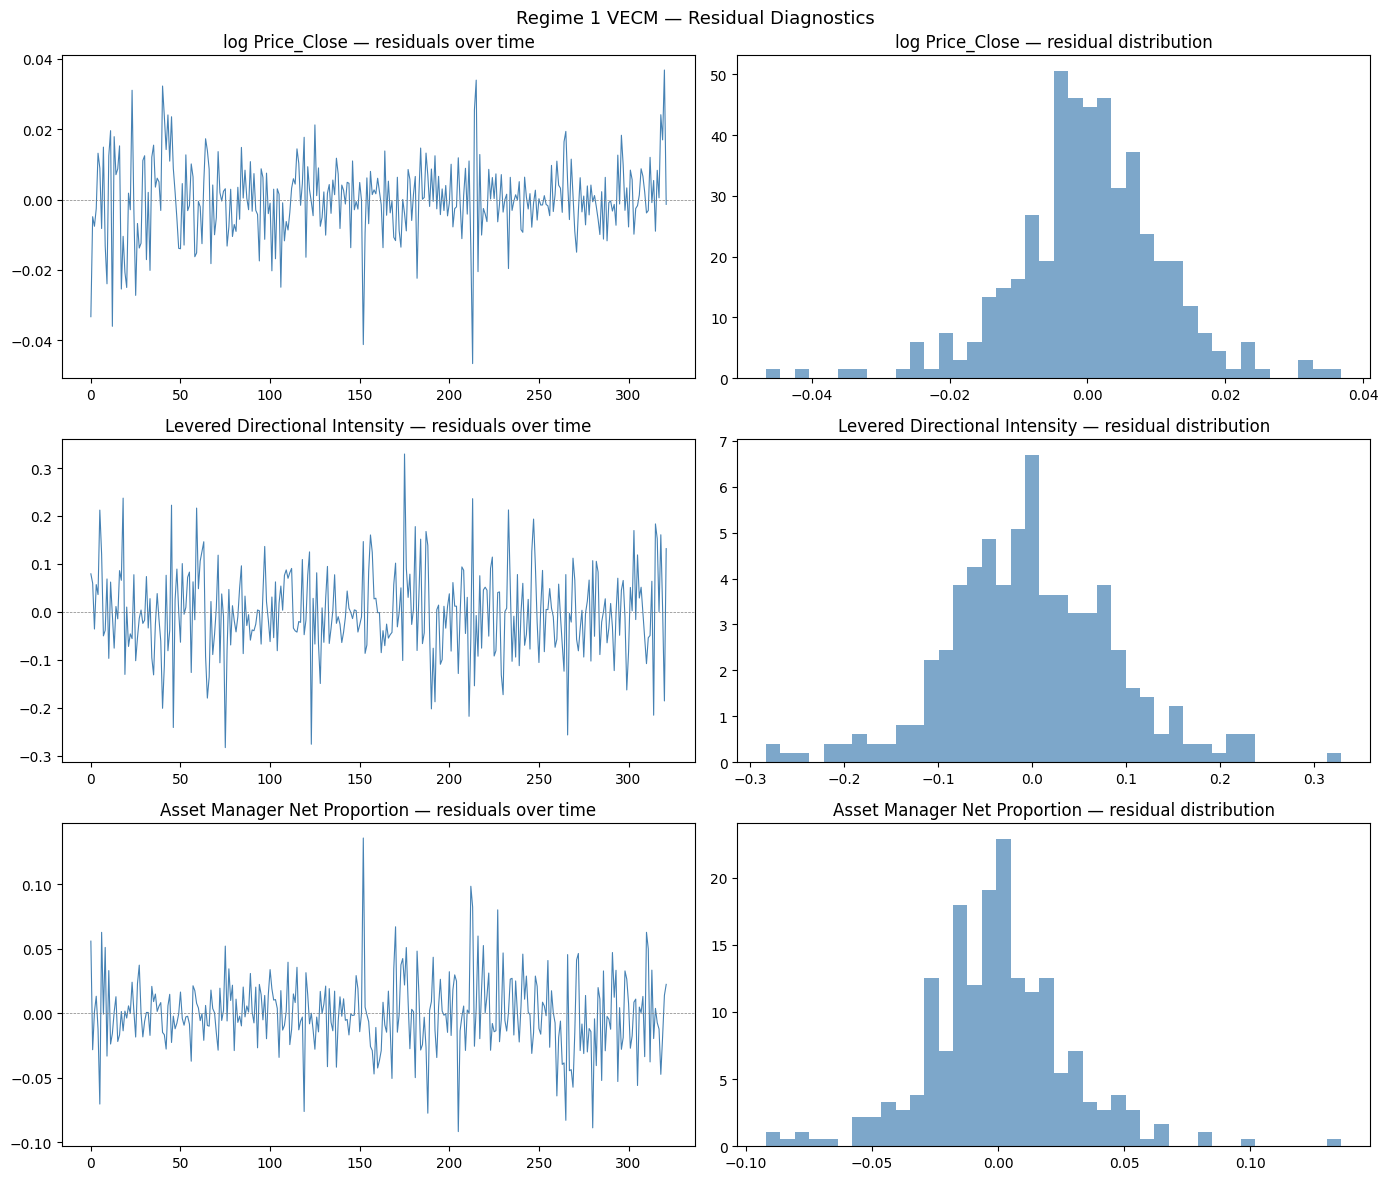

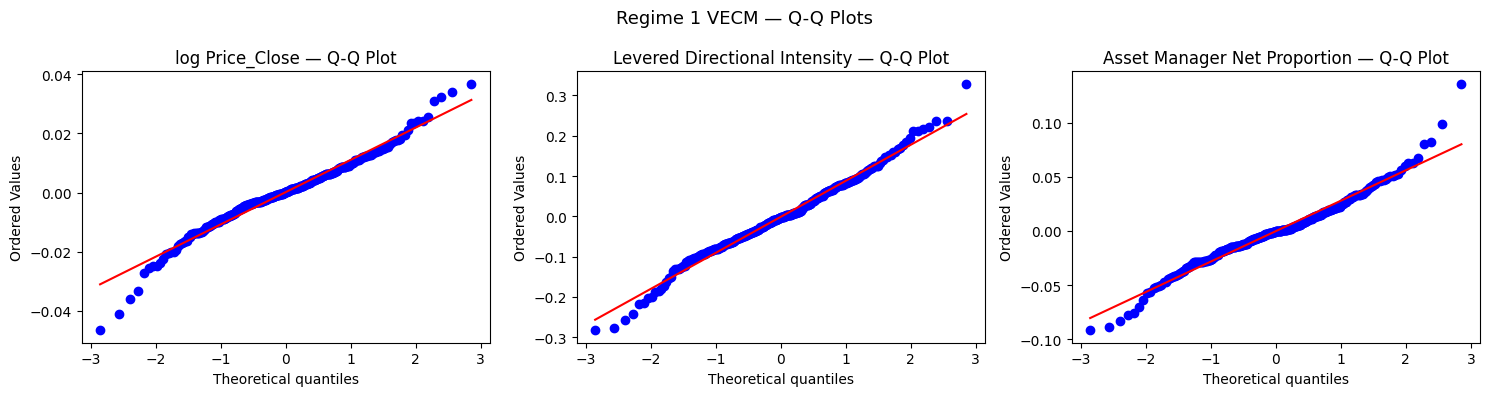

In [182]:
# Diagnostics
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera
import matplotlib.pyplot as plt
import numpy as np

resids = results_r1.resid
var_names = r1_endog.columns.tolist()

# ============================================================
# 1. LJUNG-BOX & JARQUE-BERA
# ============================================================
print(f"{'Variable':<35} {'LB lag1':>8} {'LB lag4':>8} {'LB lag8':>8} {'LB lag12':>8} {'JB stat':>10} {'JB p':>8} {'Skew':>8} {'Kurt':>8}")
print("-" * 105)

for i, var in enumerate(var_names):
    r  = resids[:, i]
    lb = acorr_ljungbox(r, lags=12, return_df=True)
    jb = jarque_bera(r)
    print(f"{var:<35} "
          f"{lb['lb_pvalue'].values[0]:>8.4f} "
          f"{lb['lb_pvalue'].values[3]:>8.4f} "
          f"{lb['lb_pvalue'].values[7]:>8.4f} "
          f"{lb['lb_pvalue'].values[11]:>8.4f} "
          f"{jb[0]:>10.2f} "
          f"{jb[1]:>8.4f} "
          f"{pd.Series(r).skew():>8.4f} "
          f"{pd.Series(r).kurtosis():>8.4f}")

# ============================================================
# 2. MULTIVARIATE PORTMANTEAU TEST (tests all equations jointly)
# ============================================================
from statsmodels.tsa.vector_ar.var_model import VAR

print("\nMultivariate Portmanteau Test (joint autocorrelation)")
print("-" * 50)
# Fit a VAR on residuals to get the joint test
var_resid = VAR(resids)
var_resid_fit = var_resid.fit(maxlags=1)
print(var_resid_fit.test_whiteness(nlags=12))

# ============================================================
# 3. RESIDUAL PLOTS
# ============================================================
fig, axes = plt.subplots(len(var_names), 2, figsize=(14, 4 * len(var_names)))

for i, var in enumerate(var_names):
    r = resids[:, i]
    
    # Time series of residuals
    axes[i, 0].plot(r, linewidth=0.8, color='steelblue')
    axes[i, 0].axhline(0, color='gray', linestyle='--', linewidth=0.5)
    axes[i, 0].set_title(f'{var} — residuals over time')
    
    # Histogram
    axes[i, 1].hist(r, bins=40, density=True, alpha=0.7, color='steelblue')
    axes[i, 1].set_title(f'{var} — residual distribution')

plt.suptitle('Regime 1 VECM — Residual Diagnostics', fontsize=13)
plt.tight_layout()
plt.show()

# ============================================================
# 4. QQ PLOTS (visual normality check)
# ============================================================
from scipy import stats

fig, axes = plt.subplots(1, len(var_names), figsize=(5 * len(var_names), 4))

for i, var in enumerate(var_names):
    r = resids[:, i]
    stats.probplot(r, dist='norm', plot=axes[i])
    axes[i].set_title(f'{var} — Q-Q Plot')

plt.suptitle('Regime 1 VECM — Q-Q Plots', fontsize=13)
plt.tight_layout()
plt.show()

In [183]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
import numpy as np

resids    = results_r1.resid
var_names = r1_endog.columns.tolist()

fig = make_subplots(rows=1, cols=len(var_names),
                    subplot_titles=var_names)

for i, var in enumerate(var_names):
    r = resids[:, i]
    
    # Get theoretical and ordered quantiles
    (theoretical_q, ordered_q), (slope, intercept, _) = stats.probplot(r, dist='norm')
    
    # Scatter points
    fig.add_trace(
        go.Scatter(
            x=theoretical_q,
            y=ordered_q,
            mode='markers',
            marker=dict(color='steelblue', size=4, opacity=0.7),
            name=var,
            showlegend=False
        ),
        row=1, col=i+1
    )
    
    # Reference line
    x_line = np.array([min(theoretical_q), max(theoretical_q)])
    y_line = slope * x_line + intercept
    
    fig.add_trace(
        go.Scatter(
            x=x_line,
            y=y_line,
            mode='lines',
            line=dict(color='red', width=1.5),
            showlegend=False
        ),
        row=1, col=i+1
    )
    
    # Axis labels
    fig.update_xaxes(title_text='Theoretical Quantiles', row=1, col=i+1)
    fig.update_yaxes(title_text='Ordered Values',        row=1, col=i+1)

fig.update_layout(
    title='Regime 1 VECM — Q-Q Plots',
    template='plotly_white',
    height=400,
    width=1100
)

fig.show()

# Regime 2

In [184]:
df_r2.columns.values.tolist()

['JPY 10Y(M)',
 'JPY 3M(M)',
 'JPY Interbank(M)',
 'US 10 Year(M)',
 'US 3M(M)',
 'US Interbank(W)',
 'Oil',
 'DXY',
 'Nikkei',
 'VIX',
 'Open_Interest_All',
 'Dealer_Positions_Long_All',
 'Dealer_Positions_Short_All',
 'Asset_Mgr_Positions_Long_All',
 'Asset_Mgr_Positions_Short_All',
 'Lev_Money_Positions_Long_All',
 'Lev_Money_Positions_Short_All',
 'Dealer Net',
 'Asset Manager Net',
 'Levered Net',
 'Dealer Long Proportion',
 'Asset Manager Long Proportion',
 'Levered Long Proportion',
 'Dealer Short Proportion',
 'Asset Manager Short Proportion',
 'Levered Short Proportion',
 'Dealer Crowding',
 'Asset Manager Crowding',
 'Levered Manager Crowding',
 'Dealer Intensity',
 'Asset Manager Intensity',
 'Levered Directional Intensity',
 'Price_Close',
 'Rate Differential 3M',
 'Rate Differential 10Y',
 'Rate Differential Interbank',
 'US Term Spread',
 'JPY Term Spread',
 'Term Spread Differential',
 'US 10Y Interbank Spread',
 'JPY 10Y Interbank Spread',
 'Term 10Y Interbank Different

In [185]:
log_diff_variables

['Price_Close',
 'VIX',
 'Oil',
 'DXY',
 'Nikkei',
 'Open_Interest_All',
 'Asset_Mgr_Positions_Long_All',
 'Lev_Money_Positions_Long_All']

In [186]:
diff_variables

['US 10 Year(M)',
 'US 3M(M)',
 'Rate Differential 3M',
 'Rate Differential 10Y',
 'US Term Spread',
 'JPY Term Spread',
 'Term Spread Differential',
 'US 10Y Interbank Spread',
 'JPY 10Y Interbank Spread',
 'Term 10Y Interbank Differential',
 'Carry to Risk',
 'Asset Manager Net',
 'Levered Net',
 'Asset Manager Net Proportion',
 'Levered Net Proportion',
 'Asset Manager Long Proportion',
 'Levered Long Proportion',
 'Asset Manager Short Proportion',
 'Asset Manager Crowding',
 'Levered Manager Crowding',
 'Levered Directional Intensity']

In [187]:
second_diff_variables

['JPY 10Y(M)',
 'JPY 3M(M)',
 'JPY Interbank(M)',
 'US Interbank(W)',
 'Rate Differential Interbank']

In [188]:
df_r2.columns.values.tolist()

['JPY 10Y(M)',
 'JPY 3M(M)',
 'JPY Interbank(M)',
 'US 10 Year(M)',
 'US 3M(M)',
 'US Interbank(W)',
 'Oil',
 'DXY',
 'Nikkei',
 'VIX',
 'Open_Interest_All',
 'Dealer_Positions_Long_All',
 'Dealer_Positions_Short_All',
 'Asset_Mgr_Positions_Long_All',
 'Asset_Mgr_Positions_Short_All',
 'Lev_Money_Positions_Long_All',
 'Lev_Money_Positions_Short_All',
 'Dealer Net',
 'Asset Manager Net',
 'Levered Net',
 'Dealer Long Proportion',
 'Asset Manager Long Proportion',
 'Levered Long Proportion',
 'Dealer Short Proportion',
 'Asset Manager Short Proportion',
 'Levered Short Proportion',
 'Dealer Crowding',
 'Asset Manager Crowding',
 'Levered Manager Crowding',
 'Dealer Intensity',
 'Asset Manager Intensity',
 'Levered Directional Intensity',
 'Price_Close',
 'Rate Differential 3M',
 'Rate Differential 10Y',
 'Rate Differential Interbank',
 'US Term Spread',
 'JPY Term Spread',
 'Term Spread Differential',
 'US 10Y Interbank Spread',
 'JPY 10Y Interbank Spread',
 'Term 10Y Interbank Different

In [189]:
# All cointegrated variables are endogenous
r2_endog = df_r2[['log Price_Close',
                   'JPY Term Spread', ]].dropna()

r2_exog  = df_r2[['Rate Differential 10Y Delta',
                   'Asset Manager Net Proportion Delta', 
                   'log Nikkei Delta', 
                   'log VIX Delta']].dropna()

# Align indices
common_idx = r2_endog.index.intersection(r2_exog.index)
r2_endog   = r2_endog.loc[common_idx]
r2_exog    = r2_exog.loc[common_idx]

print(f"Regime 2 observations: {len(r2_endog)}")

# Re-run Johansen with all 4 endogenous variables to get correct coint rank
johansen = coint_johansen(r2_endog, det_order=0, k_ar_diff=1)

print(f"\n{'':>6} {'Trace Stat':>12} {'CV 90%':>10} {'CV 95%':>10} {'CV 99%':>10} {'Sig':>5}")
print("-" * 60)
for i in range(len(r2_endog.columns)):
    trace = johansen.lr1[i]
    cv90, cv95, cv99 = johansen.cvt[i]
    sig = "***" if trace > cv99 else "**" if trace > cv95 else "*" if trace > cv90 else ""
    print(f"r<={i:<3} {trace:>12.4f} {cv90:>10.4f} {cv95:>10.4f} {cv99:>10.4f} {sig:>5}")

# Lag selection with correct endog
lag_order = select_order(r2_endog, maxlags=12,
                          deterministic='ci',
                          exog=r2_exog)
print(lag_order.summary())

# Fit VECM — update coint_rank based on Johansen result above
model_r2 = VECM(r2_endog,
                k_ar_diff=1,
                coint_rank=1,        # update after Johansen
                deterministic='ci',
                exog=r2_exog)

results_r2 = model_r2.fit()
print(results_r2.summary())

Regime 2 observations: 192

         Trace Stat     CV 90%     CV 95%     CV 99%   Sig
------------------------------------------------------------
r<=0        15.2468    13.4294    15.4943    19.9349     *
r<=1         2.5816     2.7055     3.8415     6.6349      
 VECM Order Selection (* highlights the minimums) 
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0      -14.48*     -14.20*  5.131e-07*     -14.37*
1       -14.46      -14.11   5.242e-07      -14.32
2       -14.42      -13.99   5.471e-07      -14.25
3       -14.40      -13.90   5.572e-07      -14.20
4       -14.42      -13.85   5.492e-07      -14.18
5       -14.41      -13.76   5.551e-07      -14.15
6       -14.38      -13.67   5.690e-07      -14.09
7       -14.35      -13.57   5.866e-07      -14.03
8       -14.31      -13.46   6.101e-07      -13.97
9       -14.30      -13.37   6.210e-07      -13.92
10      -14.27      -13.27   6.400e-07      -13.86
11      -14.23      

Variable                             LB lag1  LB lag4  LB lag8 LB lag12    JB stat     JB p     Skew     Kurt
---------------------------------------------------------------------------------------------------------
log Price_Close                       0.3205   0.6392   0.8582   0.9506       4.22   0.1211  -0.3364   0.3368
JPY Term Spread                       0.8207   0.8775   0.3060   0.1958    1115.77   0.0000  -0.7668  12.1220

Multivariate Portmanteau Test (joint autocorrelation)
--------------------------------------------------
<statsmodels.tsa.vector_ar.hypothesis_test_results.WhitenessTestResults object. H_0: residual autocorrelation up to lag 12 is zero: fail to reject at 5% significance level. Test statistic: 37.635, critical value: 60.481>, p-value: 0.740>


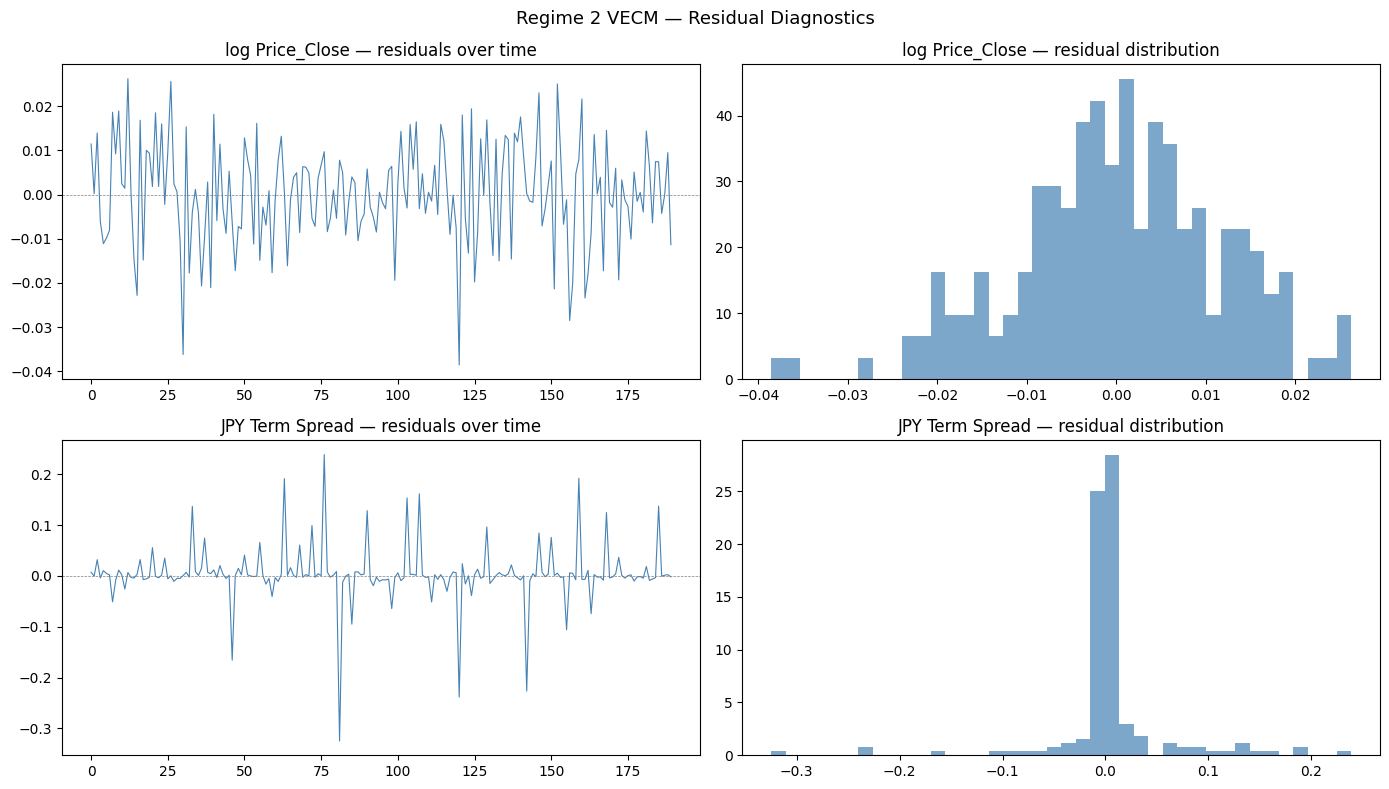

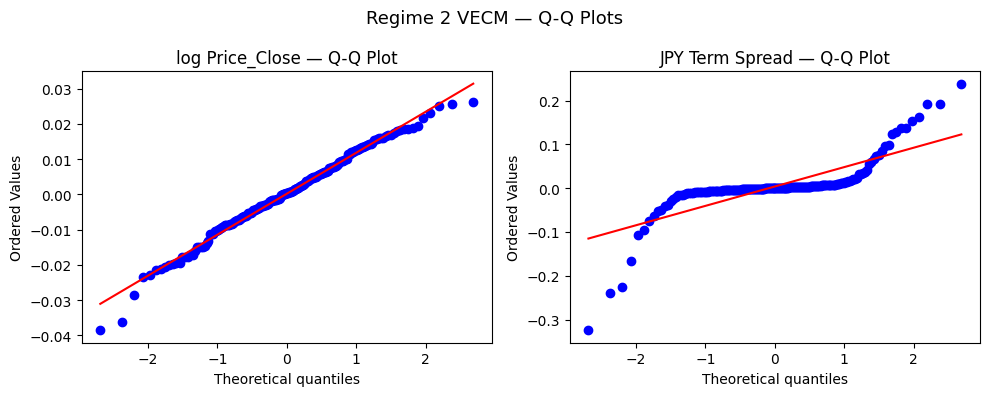

In [190]:
# Diagnostics
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera
import matplotlib.pyplot as plt
import numpy as np

resids = results_r2.resid
var_names = r2_endog.columns.tolist()

# ============================================================
# 1. LJUNG-BOX & JARQUE-BERA
# ============================================================
print(f"{'Variable':<35} {'LB lag1':>8} {'LB lag4':>8} {'LB lag8':>8} {'LB lag12':>8} {'JB stat':>10} {'JB p':>8} {'Skew':>8} {'Kurt':>8}")
print("-" * 105)

for i, var in enumerate(var_names):
    r  = resids[:, i]
    lb = acorr_ljungbox(r, lags=12, return_df=True)
    jb = jarque_bera(r)
    print(f"{var:<35} "
          f"{lb['lb_pvalue'].values[0]:>8.4f} "
          f"{lb['lb_pvalue'].values[3]:>8.4f} "
          f"{lb['lb_pvalue'].values[7]:>8.4f} "
          f"{lb['lb_pvalue'].values[11]:>8.4f} "
          f"{jb[0]:>10.2f} "
          f"{jb[1]:>8.4f} "
          f"{pd.Series(r).skew():>8.4f} "
          f"{pd.Series(r).kurtosis():>8.4f}")

# ============================================================
# 2. MULTIVARIATE PORTMANTEAU TEST (tests all equations jointly)
# ============================================================
from statsmodels.tsa.vector_ar.var_model import VAR

print("\nMultivariate Portmanteau Test (joint autocorrelation)")
print("-" * 50)
# Fit a VAR on residuals to get the joint test
var_resid = VAR(resids)
var_resid_fit = var_resid.fit(maxlags=1)
print(var_resid_fit.test_whiteness(nlags=12))

# ============================================================
# 3. RESIDUAL PLOTS
# ============================================================
fig, axes = plt.subplots(len(var_names), 2, figsize=(14, 4 * len(var_names)))

for i, var in enumerate(var_names):
    r = resids[:, i]
    
    # Time series of residuals
    axes[i, 0].plot(r, linewidth=0.8, color='steelblue')
    axes[i, 0].axhline(0, color='gray', linestyle='--', linewidth=0.5)
    axes[i, 0].set_title(f'{var} — residuals over time')
    
    # Histogram
    axes[i, 1].hist(r, bins=40, density=True, alpha=0.7, color='steelblue')
    axes[i, 1].set_title(f'{var} — residual distribution')

plt.suptitle('Regime 2 VECM — Residual Diagnostics', fontsize=13)
plt.tight_layout()
plt.show()

# ============================================================
# 4. QQ PLOTS (visual normality check)
# ============================================================
from scipy import stats

fig, axes = plt.subplots(1, len(var_names), figsize=(5 * len(var_names), 4))

for i, var in enumerate(var_names):
    r = resids[:, i]
    stats.probplot(r, dist='norm', plot=axes[i])
    axes[i].set_title(f'{var} — Q-Q Plot')

plt.suptitle('Regime 2 VECM — Q-Q Plots', fontsize=13)
plt.tight_layout()
plt.show()

In [191]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
import numpy as np

resids    = results_r2.resid
var_names = r2_endog.columns.tolist()

fig = make_subplots(rows=1, cols=len(var_names),
                    subplot_titles=var_names)

for i, var in enumerate(var_names):
    r = resids[:, i]
    
    # Get theoretical and ordered quantiles
    (theoretical_q, ordered_q), (slope, intercept, _) = stats.probplot(r, dist='norm')
    
    # Scatter points
    fig.add_trace(
        go.Scatter(
            x=theoretical_q,
            y=ordered_q,
            mode='markers',
            marker=dict(color='steelblue', size=4, opacity=0.7),
            name=var,
            showlegend=False
        ),
        row=1, col=i+1
    )
    
    # Reference line
    x_line = np.array([min(theoretical_q), max(theoretical_q)])
    y_line = slope * x_line + intercept
    
    fig.add_trace(
        go.Scatter(
            x=x_line,
            y=y_line,
            mode='lines',
            line=dict(color='red', width=1.5),
            showlegend=False
        ),
        row=1, col=i+1
    )
    
    # Axis labels
    fig.update_xaxes(title_text='Theoretical Quantiles', row=1, col=i+1)
    fig.update_yaxes(title_text='Ordered Values',        row=1, col=i+1)

fig.update_layout(
    title='Regime 2 VECM — Q-Q Plots',
    template='plotly_white',
    height=400,
    width=1100
)

fig.show()

In [192]:
df[[
    'Price_Close',
    'JPY Term Spread',
    'Levered Directional Intensity',
    'Asset Manager Net Proportion',
    'Levered Net',
    'Asset Manager Net',
    'Rate Differential 3M',
    'Rate Differential 10Y',
    'Carry to Risk',
    'Oil',
    'VIX',
    'Nikkei'
]]

,Price_Close,JPY Term Spread,Levered Directional Intensity,Asset Manager Net Proportion,Levered Net,Asset Manager Net,Rate Differential 3M,Rate Differential 10Y,Carry to Risk,Oil,VIX,Nikkei
2016-01-10,117.650002,-0.07400,-0.001660,-0.127288,-216,-33934,0.40100,1.995,0.019475,33.970001,20.590000,18075.0
2016-01-17,117.384003,-0.07400,0.066767,-0.109861,8879,-30324,0.40100,1.995,0.016502,31.410000,24.299999,17410.0
2016-01-24,118.227997,-0.07400,0.126223,-0.101034,17381,-28392,0.40100,1.995,0.015024,29.530001,26.690001,16480.0
2016-01-31,120.839996,-0.07400,0.110550,-0.128274,14323,-34787,0.40100,1.995,0.017822,31.450001,22.500000,17090.0
2016-02-07,115.667999,-0.16300,0.045976,-0.072141,5423,-20084,0.44200,1.845,0.018905,30.889999,23.379999,16585.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-02,154.203995,0.99864,-0.476547,0.230711,-64057,81142,3.05364,2.285,0.180582,60.570000,16.910000,51405.0
2025-11-09,154.203995,0.99864,-0.476547,0.230711,-64057,81142,3.05364,2.285,0.160718,60.560001,19.000000,51265.0
2025-11-16,155.272995,0.99864,-0.456121,0.196832,-69220,71204,3.05364,2.285,0.153991,60.090000,19.830000,50490.0
2025-11-23,156.938995,0.99864,-0.430170,0.191226,-61889,71734,3.05364,2.285,0.129063,59.439999,23.660000,49325.0


In [193]:
df

,JPY 10Y(M),JPY 3M(M),JPY Interbank(M),US 10 Year(M),US 3M(M),US Interbank(W),Oil,DXY,Nikkei,VIX,...,JPY 10Y(M) Delta,JPY 10Y(M) D2,JPY 3M(M) Delta,JPY 3M(M) D2,JPY Interbank(M) Delta,JPY Interbank(M) D2,US Interbank(W) Delta,US Interbank(W) D2,Rate Differential Interbank Delta,Rate Differential Interbank D2
2016-01-10,0.095,0.16900,0.070,2.09,0.57,0.340000,33.970001,99.180000,18075.0,20.590000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-17,0.095,0.16900,0.070,2.09,0.57,0.340000,31.410000,98.730003,17410.0,24.299999,...,0.00,NaN,0.00000,NaN,0.000,NaN,0.000000,NaN,0.000000,NaN
2016-01-24,0.095,0.16900,0.070,2.09,0.57,0.340000,29.530001,99.059998,16480.0,26.690001,...,0.00,0.00,0.00000,0.00000,0.000,0.000,0.000000,0.000000,0.000000,0.000000
2016-01-31,0.095,0.16900,0.070,2.09,0.57,0.340000,31.450001,99.360001,17090.0,22.500000,...,0.00,0.00,0.00000,0.00000,0.000,0.000,0.000000,0.000000,0.000000,0.000000
2016-02-07,-0.065,0.09800,0.030,1.78,0.54,0.380000,30.889999,97.029999,16585.0,23.379999,...,-0.16,-0.16,-0.07100,-0.07100,-0.040,-0.040,0.040000,0.040000,0.080000,0.080000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-02,1.805,0.80636,0.478,4.09,3.86,3.882727,60.570000,99.529999,51405.0,16.910000,...,0.15,0.15,-0.00273,-0.00273,0.001,0.001,-0.176162,-0.176162,-0.177162,-0.177162
2025-11-09,1.805,0.80636,0.478,4.09,3.86,3.882727,60.560001,100.220001,51265.0,19.000000,...,0.00,-0.15,0.00000,0.00273,0.000,-0.001,0.000000,0.176162,0.000000,0.177162
2025-11-16,1.805,0.80636,0.478,4.09,3.86,3.882727,60.090000,99.269997,50490.0,19.830000,...,0.00,0.00,0.00000,0.00000,0.000,0.000,0.000000,0.000000,0.000000,0.000000
2025-11-23,1.805,0.80636,0.478,4.09,3.86,3.882727,59.439999,100.230003,49325.0,23.660000,...,0.00,0.00,0.00000,0.00000,0.000,0.000,0.000000,0.000000,0.000000,0.000000


In [194]:
from arch import arch_model
import pandas as pd

def fit_garch(resids, var_index, var_name, regime_name):
    resid_price = resids[:, var_index]
    am = arch_model(resid_price * 100, vol='Garch', p=1, q=1,
                    dist='t', mean='Zero')
    garch_result = am.fit(disp='off')
    
    print(f"\n{'='*60}")
    print(f"GARCH(1,1) — {regime_name} — {var_name}")
    print(f"{'='*60}")
    print(garch_result.summary())
    
    # Clean summary table
    params = garch_result.params
    pvalues = garch_result.pvalues
    stderr = garch_result.std_err
    tstat = garch_result.tvalues
    
    print(f"\n{'Parameter':<15} {'Coef':>10} {'Std Err':>10} {'t-stat':>10} {'p-value':>10} {'Sig':>5}")
    print("-" * 65)
    for param in params.index:
        sig = "***" if pvalues[param] < 0.01 else "**" if pvalues[param] < 0.05 else "*" if pvalues[param] < 0.10 else ""
        print(f"{param:<15} {params[param]:>10.4f} {stderr[param]:>10.4f} {tstat[param]:>10.4f} {pvalues[param]:>10.4f} {sig:>5}")
    
    # Persistence
    alpha = params['alpha[1]']
    beta  = params['beta[1]']
    print(f"\nVolatility Persistence (α + β): {alpha + beta:.4f}")
    print(f"Half-life of volatility shock  : {abs(np.log(0.5) / np.log(alpha + beta)):.1f} weeks")
    
    return garch_result

# ============================================================
# Regime 1 — Log_Price residuals
# ============================================================
garch_r1 = fit_garch(
    resids    = results_r1.resid,
    var_index = 0,
    var_name  = 'Log_Price',
    regime_name = 'Regime 1 (YCC Stable)'
)

# ============================================================
# Regime 2 — Log_Price residuals  
# ============================================================
garch_r2 = fit_garch(
    resids    = results_r2.resid,
    var_index = 0,
    var_name  = 'Log_Price',
    regime_name = 'Regime 2 (Post-Divergence)'
)


GARCH(1,1) — Regime 1 (YCC Stable) — Log_Price
                          Zero Mean - GARCH Model Results                           
Dep. Variable:                            y   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.003
Vol Model:                            GARCH   Log-Likelihood:               -460.193
Distribution:      Standardized Student's t   AIC:                           928.385
Method:                  Maximum Likelihood   BIC:                           943.483
                                              No. Observations:                  322
Date:                      Wed, Mar 25 2026   Df Residuals:                      322
Time:                              02:23:33   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
-----------------------------------

In [195]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tools.sm_exceptions import InterpolationWarning
import warnings
warnings.filterwarnings('ignore', category=InterpolationWarning)

# Variables to test — levels and transformed versions
test_vars = {
    # Levels (should be non-stationary)
    'Price_Close'                    : 'Level',
    'JPY Term Spread'                : 'Level',
    'Levered Directional Intensity'  : 'Level',
    'Asset Manager Net Proportion'   : 'Level',
    'Rate Differential 3M'           : 'Level',
    'Rate Differential 10Y'          : 'Level',
    'Carry to Risk'                  : 'Level',
    'log Oil'                        : 'Level',
    'log VIX'                        : 'Level',
    'log Nikkei'                     : 'Level',
    # Transformed (should be stationary)
    'log Price_Close Delta'          : 'Transformed',
    'JPY Term Spread Delta'          : 'Transformed',
    'Levered Directional Intensity Delta' : 'Transformed',
    'Asset Manager Net Proportion Delta'  : 'Transformed',
    'Rate Differential 3M Delta'     : 'Transformed',
    'Rate Differential 10Y Delta'    : 'Transformed',
    'Carry to Risk Delta'            : 'Transformed',
    'log Oil Delta'                  : 'Transformed',
    'log VIX Delta'                  : 'Transformed',
    'log Nikkei Delta'               : 'Transformed',
}

print(f"{'Variable':<45} {'Form':<15} {'ADF stat':>9} {'ADF p':>8} {'KPSS stat':>10} {'KPSS p':>8} {'I(d)':>5}")
print("-" * 105)

for var, form in test_vars.items():
    try:
        series = df[var].dropna()
        adf    = adfuller(series, autolag='AIC')
        k      = kpss(series, regression='c', nlags='auto')
        
        stationary = (adf[1] < 0.05) and (k[1] > 0.05)
        order = 'I(0)' if stationary else 'I(1)'
        
        print(f"{var:<45} {form:<15} {adf[0]:>9.4f} {adf[1]:>8.4f} {k[0]:>10.4f} {k[1]:>8.4f} {order:>5}")
    except Exception as e:
        print(f"{var:<45} ERROR: {e}")

Variable                                      Form             ADF stat    ADF p  KPSS stat   KPSS p  I(d)
---------------------------------------------------------------------------------------------------------
Price_Close                                   Level             -0.2025   0.9382     2.5978   0.0100  I(1)
JPY Term Spread                               Level              0.0059   0.9590     2.8660   0.0100  I(1)
Levered Directional Intensity                 Level             -3.7886   0.0030     0.6980   0.0137  I(1)
Asset Manager Net Proportion                  Level             -2.7947   0.0590     0.1835   0.1000  I(1)
Rate Differential 3M                          Level             -1.8183   0.3714     1.6695   0.0100  I(1)
Rate Differential 10Y                         Level             -1.6636   0.4500     0.8999   0.0100  I(1)
Carry to Risk                                 Level             -1.5258   0.5207     1.2697   0.0100  I(1)
log Oil                               

In [196]:
from statsmodels.tsa.stattools import coint

# ============================================================
# B1: Full Sample
# ============================================================
candidates = [
    'JPY Term Spread', 'Rate Differential 3M', 'Rate Differential 10Y',
    'Carry to Risk', 'Asset Manager Net Proportion',
    'Levered Directional Intensity', 'log Oil', 'log VIX', 'log Nikkei'
]

print("FULL SAMPLE")
print(f"{'Variable':<45} {'Stat':>8} {'p-value':>10} {'Sig':>5}")
print("-" * 75)
for var in candidates:
    d = df[['log Price_Close', var]].dropna()
    stat, pvalue, _ = coint(d['log Price_Close'], d[var])
    sig = "***" if pvalue < 0.01 else "**" if pvalue < 0.05 else "*" if pvalue < 0.10 else ""
    print(f"{var:<45} {stat:>8.4f} {pvalue:>10.4f} {sig:>5}")

# ============================================================
# B2: By Regime
# ============================================================
for regime_name, regime_df in {'Regime 1 (YCC Stable)': df_r1, 
                                'Regime 2 (Post-Divergence)': df_r2}.items():
    print(f"\n{regime_name}")
    print(f"{'Variable':<45} {'Stat':>8} {'p-value':>10} {'Sig':>5}")
    print("-" * 75)
    for var in candidates:
        try:
            d = regime_df[['log Price_Close', var]].dropna()
            stat, pvalue, _ = coint(d['log Price_Close'], d[var])
            sig = "***" if pvalue < 0.01 else "**" if pvalue < 0.05 else "*" if pvalue < 0.10 else ""
            print(f"{var:<45} {stat:>8.4f} {pvalue:>10.4f} {sig:>5}")
        except Exception as e:
            print(f"{var:<45} ERROR: {e}")

FULL SAMPLE
Variable                                          Stat    p-value   Sig
---------------------------------------------------------------------------
JPY Term Spread                                -3.7962     0.0137    **
Rate Differential 3M                           -1.4731     0.7714      
Rate Differential 10Y                          -0.4179     0.9697      
Carry to Risk                                  -1.0947     0.8834      
Asset Manager Net Proportion                    0.0424     0.9868      
Levered Directional Intensity                  -1.0245     0.8981      
log Oil                                        -1.3990     0.7979      
log VIX                                        -0.4380     0.9685      
log Nikkei                                     -2.2526     0.3974      

Regime 1 (YCC Stable)
Variable                                          Stat    p-value   Sig
---------------------------------------------------------------------------
JPY Term Spread      